# Structural Backfire Analysis

For each run, we:
1. Identify all targeted nodes from the step-20000 GEXF (`target=True`)
2. **Filter seeds where targeting executed**: seeds where no run has a `target=True` node in `step_20000.gexf` are excluded (these are runs where the moderate-influencer pool was empty at step 20000, causing an early stop). Mirrors `build_valid_seeds()` in `result-summary.ipynb`.
3. Characterise targeted nodes' structural position by averaging across all targets: in-degree, betweenness centrality, local clustering coefficient, PageRank, eigenvector centrality
4. Measure the backfire effect: Δopposite − Δtarget post-share (late window minus pre-intervention baseline)
5. Scatter-plot each structural metric against backfire magnitude with Spearman correlation

The `n_targets` column records how many targets were active per run.

**Note on eigenvector centrality:** computed as the left eigenvector of the directed adjacency matrix (hub score). Falls back to NaN if power iteration fails to converge.

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import xml.etree.ElementTree as ET
from scipy import stats
from scipy.stats import fisher_exact, ks_2samp, chi2_contingency

# =========================================================================
# Global Constants
# =========================================================================
RESULTS_DIR = "./results"
SUMMARY_DIR = os.path.join(RESULTS_DIR, "BF_analysis")
os.makedirs(SUMMARY_DIR, exist_ok=True)
BINS = ["bin_0", "bin_1", "bin_2", "bin_3", "bin_4"]

# step window just before intervention = baseline; end of simulation = outcome
PRE_RANGE  = (19000, 20000)
POST_RANGE = (39000, 40000)

# Direction-relative bin labels, ordered from most-opposing to most-aligned.
# dir=+1: bin0→far_opposite, bin1→near_opposite, bin2→neutral, bin3→near_target, bin4→far_target
# dir=−1: bins are mirrored
_POS_MAP = {
     1.0: {0: 'far_opposite', 1: 'near_opposite', 2: 'neutral', 3: 'near_target', 4: 'far_target'},
    -1.0: {0: 'far_target',   1: 'near_target',   2: 'neutral', 3: 'near_opposite', 4: 'far_opposite'},
}
GROUP_ORDER  = ['far_opposite', 'near_opposite', 'neutral', 'near_target', 'far_target']
GROUP_LABELS = ['Far\nOpposite', 'Near\nOpposite', 'Neutral', 'Near\nTarget', 'Far\nTarget']

def get_relative_group(opinionclass, target_sign):
    return _POS_MAP[target_sign].get(opinionclass, 'unknown')

# =========================================================================
# Helper Functions
# =========================================================================
def _gexf_has_target(fpath):
    """Return True if any node in the GEXF has target=True."""
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag:
                elem.tag = elem.tag.split('}', 1)[1]
        attr_map = {}
        for attr in root.findall(".//attributes[@class='node']/attribute"):
            attr_map[attr.get('id')] = attr.get('title')
        for node in root.findall(".//node"):
            for av in node.findall(".//attvalue"):
                title = attr_map.get(av.get('for'), av.get('for'))
                if title == 'target' and av.get('value', '').lower() == 'true':
                    return True
    except Exception:
        pass
    return False

def build_valid_seeds(results_dir, check_step=20000):
    """
    Exclude seeds where no run has a target=True node in step_{check_step}.gexf.
    Mirrors the exclusion logic in result-summary.ipynb.
    """
    seed_dirs = glob.glob(os.path.join(results_dir, "run_*_dir_*"))
    seeds_found = set()
    for d in seed_dirs:
        m = re.match(r'run_(\d+)_dir_', os.path.basename(d))
        if m:
            seeds_found.add(int(m.group(1)))

    valid, excluded = [], []
    for seed in sorted(seeds_found):
        gexf_files = glob.glob(
            os.path.join(results_dir, f"run_{seed}_dir_*", "GEXF", "*", f"step_{check_step}.gexf")
        )
        if any(_gexf_has_target(f) for f in gexf_files):
            valid.append(seed)
        else:
            excluded.append(seed)

    print(f"Seeds with target nodes   : {valid}")
    print(f"Seeds excluded (no target): {excluded}")
    return valid

def parse_gexf_for_target(fpath):
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag:
                elem.tag = elem.tag.split('}', 1)[1]

        attr_map = {}
        for attr in root.findall(".//attributes[@class='node']/attribute"):
            attr_map[attr.get('id')] = attr.get('title')

        G = nx.DiGraph()
        target_nodes = []
        node_opinions = {}

        for node in root.findall(".//node"):
            nid = node.get('id')
            G.add_node(nid)
            for av in node.findall(".//attvalue"):
                title = attr_map.get(av.get('for'), av.get('for'))
                if title == 'target' and av.get('value', '').lower() == 'true':
                    target_nodes.append(nid)
                if title == 'opinion':
                    try:
                        node_opinions[nid] = float(av.get('value'))
                    except (TypeError, ValueError):
                        pass

        for edge in root.findall(".//edge"):
            G.add_edge(edge.get('source'), edge.get('target'))

        return G, target_nodes, node_opinions
    except Exception as e:
        print(f"  [WARN] GEXF parse failed ({fpath}): {e}")
        return None, [], {}

def _compute_modularity(G):
    """
    Directed modularity Q (Leicht & Newman 2008) with Louvain partition.
    """
    if G is None or len(G.nodes) < 4:
        return np.nan
    try:
        G_und = G.to_undirected()
        try:
            communities = nx.community.louvain_communities(G_und, seed=42)
        except AttributeError:
            communities = list(nx.community.greedy_modularity_communities(G_und))
        return nx.community.modularity(G, communities)
    except Exception:
        return np.nan

def get_target_structural_metrics(G, target_id):
    """Node-level structural indices for the targeted agent."""
    if G is None or target_id is None or target_id not in G:
        return {}

    in_degree = G.in_degree(target_id)
    bc_all = nx.betweenness_centrality(G, normalized=True)
    betweenness = bc_all.get(target_id, np.nan)
    clustering = nx.clustering(G, target_id)
    pr_all = nx.pagerank(G, alpha=0.85, max_iter=200)
    pagerank = pr_all.get(target_id, np.nan)

    try:
        ec_all = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)
        eigenvector = ec_all.get(target_id, np.nan)
    except nx.PowerIterationFailedConvergence:
        eigenvector = np.nan

    return {
        'in_degree':   in_degree,
        'betweenness': betweenness,
        'clustering':  clustering,
        'pagerank':    pagerank,
        'eigenvector': eigenvector,
    }

def get_follower_opinion_metrics(G, target_id, node_opinions, target_sign):
    """
    Opinion-based homophily metrics for the target's follower set.
    """
    if G is None or target_id is None or target_id not in G:
        return {}

    target_op = node_opinions.get(target_id, np.nan)
    followers = list(G.predecessors(target_id))
    follower_ops = np.array([node_opinions[f] for f in followers if f in node_opinions])

    if len(follower_ops) == 0:
        return {
            'target_opinion':          target_op,
            'follower_mean_opinion':   np.nan,
            'follower_opinion_std':    np.nan,
            'follower_homophily_frac': np.nan,
            'follower_dir_alignment':  np.nan,
        }

    same_sign_as_target = np.sign(follower_ops) == np.sign(target_op) if not np.isnan(target_op) else np.nan
    same_sign_as_dir    = np.sign(follower_ops) == np.sign(target_sign)

    return {
        'target_opinion':          target_op,
        'follower_mean_opinion':   float(np.mean(follower_ops)),
        'follower_opinion_std':    float(np.std(follower_ops)),
        'follower_homophily_frac': float(np.mean(same_sign_as_target)) if not np.isnan(target_op) else np.nan,
        'follower_dir_alignment':  float(np.mean(same_sign_as_dir)),
    }

def average_metrics(metric_list):
    """Average a list of metric dicts across targets, ignoring NaN per key."""
    if not metric_list:
        return {}
    keys = metric_list[0].keys()
    result = {}
    for k in keys:
        vals = [m[k] for m in metric_list
                if k in m and not (isinstance(m[k], float) and np.isnan(m[k]))]
        result[k] = float(np.mean(vals)) if vals else np.nan
    return result

def compute_backfire_effect(run_dir, target_sign, pre_range, post_range):
    post_dir = os.path.join(run_dir, "posts")
    files = glob.glob(os.path.join(post_dir, "post_result_*.csv"))
    if not files: return np.nan
    dfs = []
    for f in files:
        try: dfs.append(pd.read_csv(f))
        except: pass
    if not dfs: return np.nan
    df = pd.concat(dfs, ignore_index=True).sort_values('step')

    if target_sign > 0:
        target_bins, opposite_bins = ["bin_3", "bin_4"], ["bin_0", "bin_1"]
    else:
        target_bins, opposite_bins = ["bin_0", "bin_1"], ["bin_3", "bin_4"]

    def mean_share(df, bins, step_range):
        mask = (df['step'] >= step_range[0]) & (df['step'] <= step_range[1])
        sub = df[mask].copy()
        if sub.empty: return np.nan
        total = sub[BINS].sum(axis=1).replace(0, np.nan)
        return (sub[bins].sum(axis=1) / total).mean()

    t_pre, t_post = mean_share(df, target_bins, pre_range), mean_share(df, target_bins, post_range)
    o_pre, o_post = mean_share(df, opposite_bins, pre_range), mean_share(df, opposite_bins, post_range)
    return (o_post - o_pre) - (t_post - t_pre)

def _parse_gexf_full(fpath):
    """One-pass GEXF parse -> (DiGraph, target_ids, {nid: {opinionclass, postprob}})."""
    try:
        tree = ET.parse(fpath); root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag: elem.tag = elem.tag.split('}', 1)[1]
        attr_map = {a.get('id'): a.get('title') for a in root.findall(".//attributes[@class='node']/attribute")}
        G = nx.DiGraph(); target_ids, agents = [], {}
        for node in root.findall(".//node"):
            nid = node.get('id'); G.add_node(nid)
            d = {'opinionclass': -1, 'postprob': np.nan}
            for av in node.findall(".//attvalue"):
                t, v = attr_map.get(av.get('for'), av.get('for')), av.get('value', '')
                if t == 'opinionClass':
                    try: d['opinionclass'] = int(v)
                    except: pass
                elif t == 'postProb':
                    try: d['postprob'] = float(v)
                    except: pass
                elif t == 'target' and v.lower() == 'true': target_ids.append(nid)
            agents[nid] = d
        for edge in root.findall(".//edge"): G.add_edge(edge.get('source'), edge.get('target'))
        return G, target_ids, agents
    except Exception: return None, [], {}

def _gexf_path(run_dir, step):
    fs = glob.glob(os.path.join(run_dir, 'GEXF', '*', f'step_{step}.gexf'))
    return fs[0] if fs else None

def parse_gexf_agent_attrs(fpath):
    """Parse one GEXF snapshot. Returns {node_id: {opinion, postprob, opinionclass, is_target}}."""
    try:
        tree = ET.parse(fpath); root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag: elem.tag = elem.tag.split('}', 1)[1]
        attr_map = {a.get('id'): a.get('title') for a in root.findall(".//attributes[@class='node']/attribute")}
        agents = {}
        for node in root.findall(".//node"):
            nid = node.get('id')
            d = {'opinion': np.nan, 'postprob': np.nan, 'opinionclass': np.nan, 'is_target': False}
            for av in node.findall(".//attvalue"):
                t, v = attr_map.get(av.get('for'), av.get('for')), av.get('value', '')
                if t == 'opinion':
                    try: d['opinion'] = float(v)
                    except: pass
                elif t == 'postProb':
                    try: d['postprob'] = float(v)
                    except: pass
                elif t == 'opinionClass':
                    try: d['opinionclass'] = int(v)
                    except: pass
                elif t == 'target': d['is_target'] = (v.lower() == 'true')
            agents[nid] = d
        return agents
    except Exception: return {}

def compute_run_agent_deltas(run_dir, pre_steps, post_steps,
                              class_ref_step=15000, target_ref_step=20000):
    gexf_base = os.path.join(run_dir, "GEXF")
    def _load(step):
        fs = glob.glob(os.path.join(gexf_base, "*", f"step_{step}.gexf"))
        return parse_gexf_agent_attrs(fs[0]) if fs else {}
    ref_class, ref_target = _load(class_ref_step), _load(target_ref_step)
    if not ref_class: return []
    pre_snaps, post_snaps = [_load(s) for s in pre_steps if _load(s)], [_load(s) for s in post_steps if _load(s)]
    if not pre_snaps or not post_snaps: return []
    rows = []
    for nid, ref_c in ref_class.items():
        if ref_target.get(nid, {}).get('is_target', False): continue
        p_ops = [sn[nid]['opinion']  for sn in pre_snaps  if nid in sn and not np.isnan(sn[nid]['opinion'])]
        p_pps = [sn[nid]['postprob'] for sn in pre_snaps  if nid in sn and not np.isnan(sn[nid]['postprob'])]
        q_ops = [sn[nid]['opinion']  for sn in post_snaps if nid in sn and not np.isnan(sn[nid]['opinion'])]
        q_pps = [sn[nid]['postprob'] for sn in post_snaps if nid in sn and not np.isnan(sn[nid]['postprob'])]
        if not p_ops or not p_pps or not q_ops or not q_pps: continue
        oc = ref_c['opinionclass']
        rows.append({
            'node_id': nid, 'opinionclass': int(oc) if not np.isnan(oc) else -1,
            'pre_opinion': np.mean(p_ops), 'post_opinion': np.mean(q_ops), 'delta_opinion': np.mean(q_ops) - np.mean(p_ops),
            'pre_postprob': np.mean(p_pps), 'post_postprob': np.mean(q_pps), 'delta_postprob': np.mean(q_pps) - np.mean(p_pps)
        })
    return rows

def load_unfollow_timeseries_local(run_dir, target_sign, window=100):
    metric_dir = os.path.join(run_dir, 'metrics')
    files = glob.glob(os.path.join(metric_dir, 'result_*.csv'))
    if not files: return None
    dfs = [pd.read_csv(f) for f in files]
    df = pd.concat(dfs).sort_values('step').reset_index(drop=True)
    pmap = _POS_MAP[target_sign]
    
    # Initialize GROUP_ORDER columns to zero
    for g in GROUP_ORDER:
        df[g] = 0.0
        
    for i in range(5):
        col = f'targetUnfollow_{i}'
        if col in df.columns:
            group = pmap[i]
            df[group] = df[group] + df[col]
            
    df['window_idx'] = df['step'] // window
    agg = df.groupby('window_idx')[GROUP_ORDER].sum()
    agg['step'] = agg.index * window
    return agg.reset_index(drop=True)

def classify_seed(d):
    if -1.0 not in d or 1.0 not in d: return None
    b_neg, b_pos = d[-1.0]['backfire_effect'], d[1.0]['backfire_effect']
    if b_neg > 0 and b_pos > 0: return 'both'
    elif b_neg <= 0 and b_pos <= 0: return 'neither'
    else: return 'one'

def make_seed_row(seed, d, seed_class_dict):
    base = dict(d[-1.0])
    base['backfire_neg']  = d[-1.0]['backfire_effect']
    base['backfire_pos']  = d[1.0]['backfire_effect']
    base['mean_backfire'] = (d[-1.0]['backfire_effect'] + d[1.0]['backfire_effect']) / 2
    base['backfire_class'] = seed_class_dict[seed]
    return base

print("Global constants and functions defined.")
SEEDS = build_valid_seeds(RESULTS_DIR)


Global constants and functions defined.
Seeds with target nodes   : [0, 1, 2, 3, 5, 6, 7, 9]
Seeds excluded (no target): [4, 8]


In [2]:
# The build_valid_seeds() call is now in the definitions cell above.
# This cell is kept to maintain the notebook's logical progression but is emptied of redundant logic.
print(f"Seeds with target nodes: {SEEDS}")

Seeds with target nodes: [0, 1, 2, 3, 5, 6, 7, 9]


In [3]:
# ---------------------------------------------------------------------------
# Main data collection loop
# ---------------------------------------------------------------------------
records = []
run_dirs = sorted(glob.glob(os.path.join(RESULTS_DIR, "run_*")))
print(f"Found {len(run_dirs)} run directories.")

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m:
        continue
    seed        = int(m.group(1))
    target_sign = float(m.group(2))

    if SEEDS is not None and seed not in SEEDS:
        continue

    gexf_files = glob.glob(os.path.join(run_dir, "GEXF", "*", "step_20000.gexf"))
    if not gexf_files:
        print(f"  [SKIP] {dirname}: no step_20000 GEXF")
        continue

    print(f"Processing {dirname} ...", end=" ")
    G, target_ids, node_opinions = parse_gexf_for_target(gexf_files[0])
    if not target_ids:
        print("no target nodes (pool was empty, run excluded)")
        continue

    # Compute per-target metrics then average across targets (characterises the intervention)
    struct_list    = [get_target_structural_metrics(G, tid) for tid in target_ids]
    homophily_list = [get_follower_opinion_metrics(G, tid, node_opinions, target_sign) for tid in target_ids]
    struct    = average_metrics(struct_list)
    homophily = average_metrics(homophily_list)

    # Global network modularity Q (graph-level, not per-node)
    graph_modularity = _compute_modularity(G)

    backfire = compute_backfire_effect(run_dir, target_sign, PRE_RANGE, POST_RANGE)

    records.append({
        'run_id':          dirname,
        'seed':            seed,
        'target_sign':     target_sign,
        'target_id':       ';'.join(target_ids),
        'n_targets':       len(target_ids),
        'backfire_effect': backfire,
        'modularity':      graph_modularity,
        **struct,
        **homophily,
    })
    print(f"targets={target_ids}, n={len(target_ids)}, "
          f"dir_align={homophily.get('follower_dir_alignment', float('nan')):.3f}, "
          f"homophily={homophily.get('follower_homophily_frac', float('nan')):.3f}, "
          f"modularity={graph_modularity:.4f}, "
          f"backfire={backfire:.4f}")

df = pd.DataFrame(records)
print(f"\nCollected {len(df)} valid runs.")
print(df[['seed', 'target_sign', 'n_targets', 'in_degree', 'betweenness', 'clustering',
          'pagerank', 'eigenvector', 'modularity',
          'target_opinion', 'follower_mean_opinion', 'follower_opinion_std',
          'follower_homophily_frac', 'follower_dir_alignment',
          'backfire_effect']].describe())

Found 20 run directories.
Processing run_0_dir_-1.0 ... targets=['0'], n=1, dir_align=0.369, homophily=0.631, modularity=0.3502, backfire=0.1077
Processing run_0_dir_1.0 ... targets=['0'], n=1, dir_align=0.631, homophily=0.631, modularity=0.3502, backfire=0.0846
Processing run_1_dir_-1.0 ... targets=['4'], n=1, dir_align=0.723, homophily=0.723, modularity=0.4971, backfire=0.0343
Processing run_1_dir_1.0 ... targets=['4'], n=1, dir_align=0.277, homophily=0.723, modularity=0.4971, backfire=-0.0401
Processing run_2_dir_-1.0 ... targets=['6'], n=1, dir_align=0.337, homophily=0.337, modularity=0.3453, backfire=-0.0416
Processing run_2_dir_1.0 ... targets=['6'], n=1, dir_align=0.663, homophily=0.337, modularity=0.3453, backfire=0.1649
Processing run_3_dir_-1.0 ... targets=['11'], n=1, dir_align=0.365, homophily=0.365, modularity=0.3120, backfire=-0.0208
Processing run_3_dir_1.0 ... targets=['11'], n=1, dir_align=0.635, homophily=0.365, modularity=0.3120, backfire=0.0608
Processing run_5_dir_

In [4]:
# ---------------------------------------------------------------------------
# Seed-level collapse: signed mean backfire_effect across both directions.
#
# mean_backfire = (backfire_neg + backfire_pos) / 2
#
# Cancellation is intentional: if dir=−1 gives +0.06 and dir=+1 gives −0.06
# (the typical mirror case), the seed-level mean is ~0, correctly indicating
# no net backfire tendency. A positive mean_backfire means backfire dominates
# regardless of direction; a negative mean means manipulation consistently works.
# ---------------------------------------------------------------------------
from collections import defaultdict

_by_seed = defaultdict(dict)
for _, row in df.iterrows():
    _by_seed[int(row['seed'])][row['target_sign']] = row

seed_records = []
for seed in sorted(_by_seed.keys()):
    d = _by_seed[seed]
    if -1.0 not in d or 1.0 not in d:
        continue  # require both direction runs
    base = d[-1.0].to_dict()
    base['backfire_neg']        = d[-1.0]['backfire_effect']
    base['backfire_pos']        = d[1.0]['backfire_effect']
    base['mean_backfire']       = (d[-1.0]['backfire_effect'] + d[1.0]['backfire_effect']) / 2
    base['follower_alignment_pos'] = d[1.0]['follower_dir_alignment']
    seed_records.append(base)

df_seed = pd.DataFrame(seed_records).reset_index(drop=True)
print(f"Seed-level frame: {len(df_seed)} seeds")
print(df_seed[['seed', 'in_degree', 'betweenness', 'clustering',
               'pagerank', 'eigenvector', 'modularity', 'mean_backfire']].describe())

Seed-level frame: 8 seeds
           seed   in_degree  betweenness  clustering  pagerank   eigenvector  \
count  8.000000    8.000000     8.000000    8.000000  8.000000  8.000000e+00   
mean   4.125000  368.750000     0.000181    0.014252  0.054754  9.748272e-02   
std    3.136764  224.216573     0.000150    0.009640  0.062319  1.802574e-01   
min    0.000000  123.000000     0.000000    0.003187  0.004754  3.516643e-23   
25%    1.750000  183.250000     0.000073    0.008645  0.012456  1.871483e-05   
50%    4.000000  313.500000     0.000171    0.010936  0.015915  2.162865e-05   
75%    6.250000  601.000000     0.000224    0.018398  0.101778  9.533864e-02   
max    9.000000  637.000000     0.000484    0.031121  0.165696  4.004997e-01   

       modularity  mean_backfire  
count    8.000000       8.000000  
mean     0.368902       0.037237  
std      0.060326       0.032820  
min      0.311997      -0.002886  
25%      0.341469       0.015200  
50%      0.345133       0.035246  
75%     

---
## Section 1: All-Seeds Analysis

The analyses in this section pool all 70 valid seeds across both manipulation directions. They characterise how the structural position and opinion environment of the targeted node predict backfire magnitude, averaged over all seeds and both intervention directions. No split by backfire class is applied here.

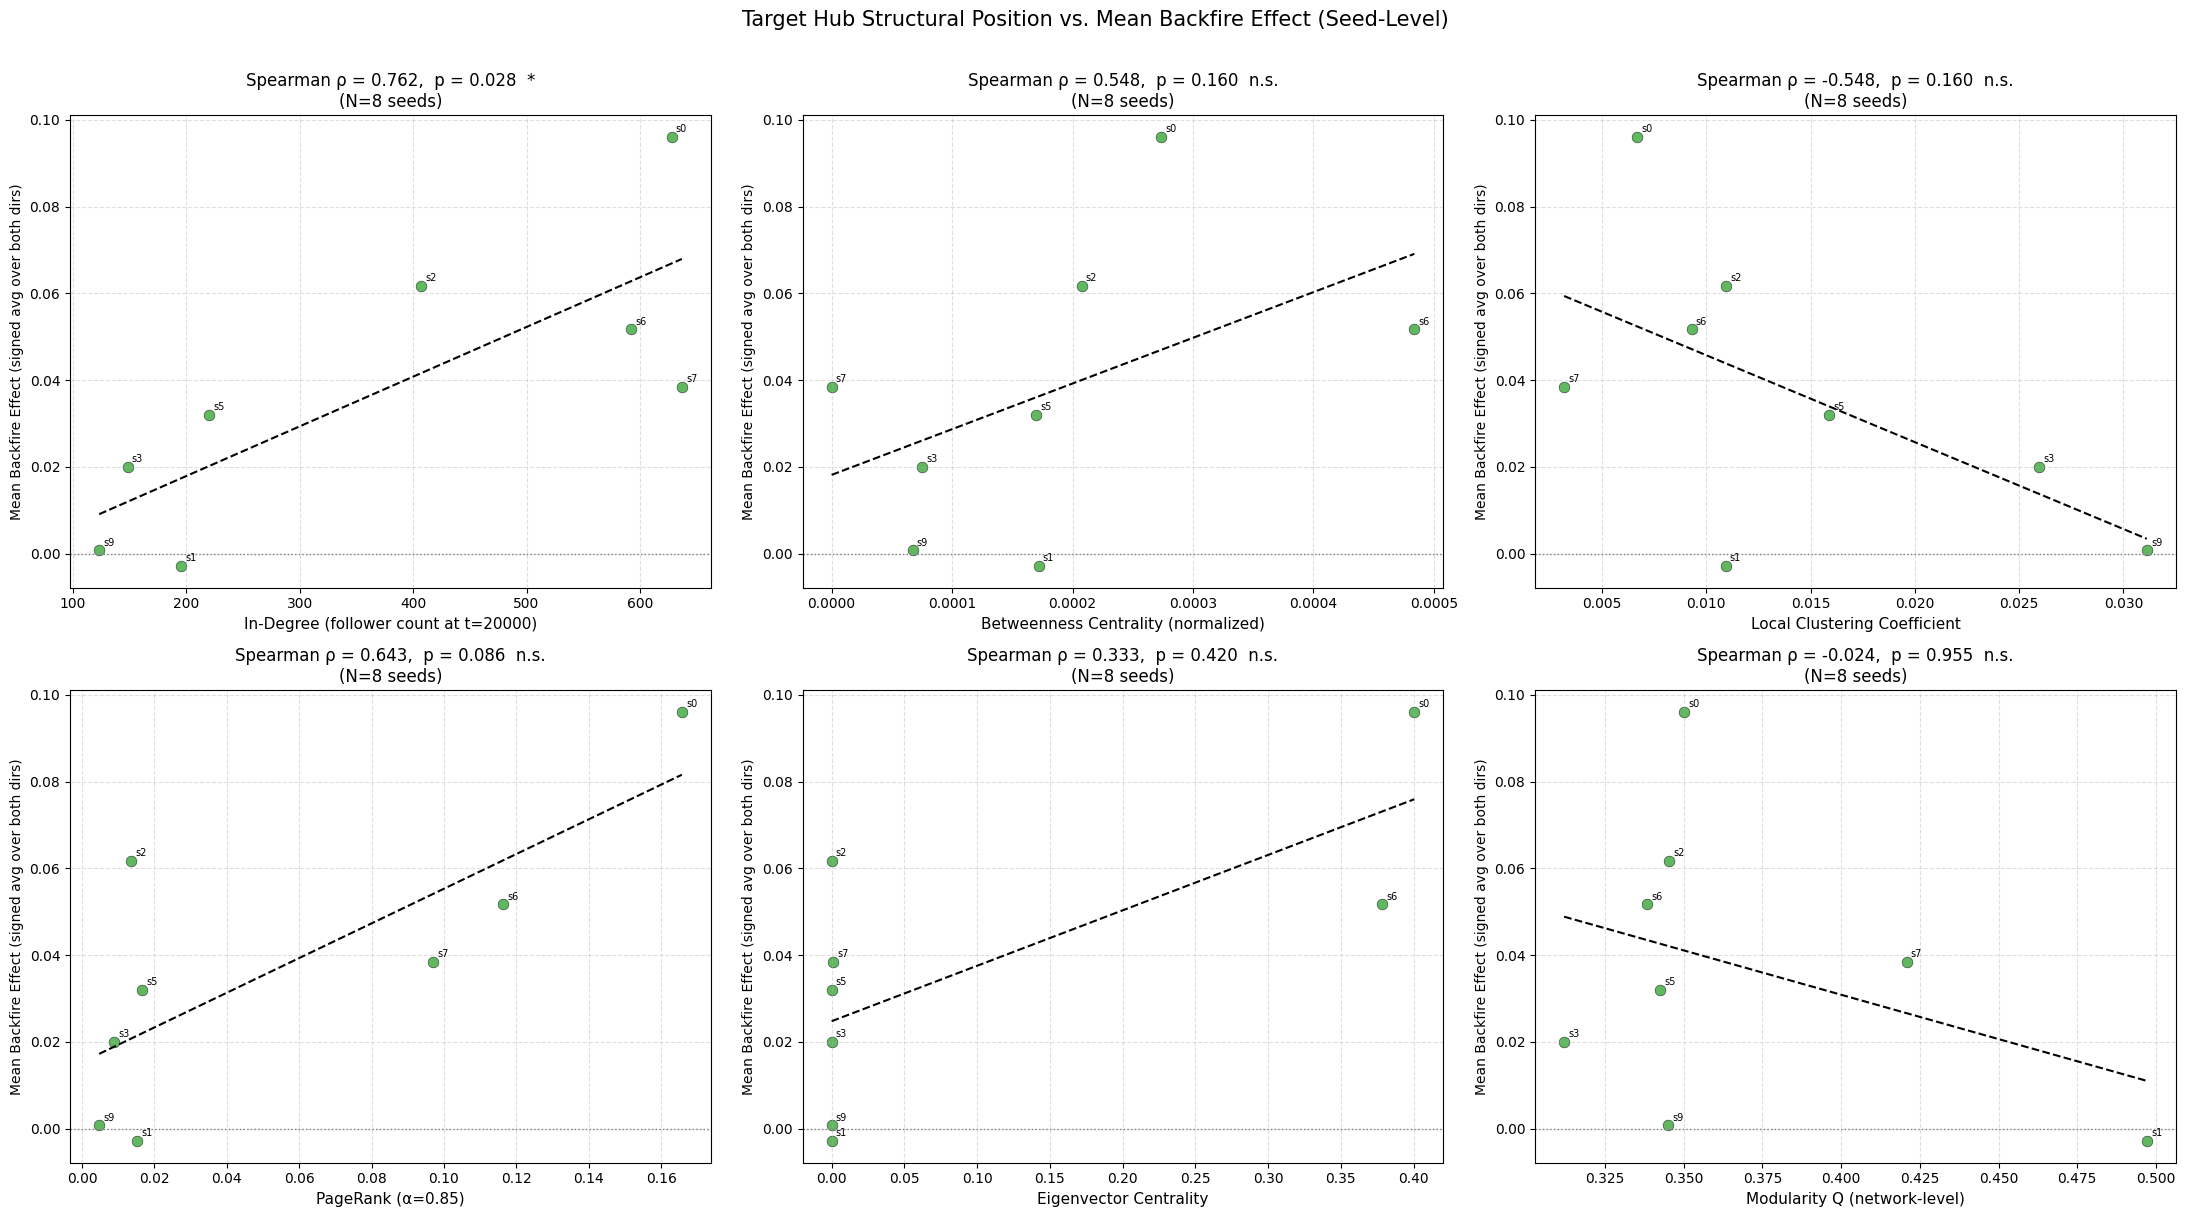

Figure saved to results/summary/BF_analysis/structural_backfire_seedlevel.png


In [5]:
# ---------------------------------------------------------------------------
# Scatter plots: structural metric (x) vs mean signed backfire (y)
# Y-axis = (backfire_neg + backfire_pos) / 2 — cancellation permitted.
# ---------------------------------------------------------------------------
STRUCTURAL_METRICS = [
    ('in_degree',   'In-Degree (follower count at t=20000)'),
    ('betweenness', 'Betweenness Centrality (normalized)'),
    ('clustering',  'Local Clustering Coefficient'),
    ('pagerank',    'PageRank (α=0.85)'),
    ('eigenvector', 'Eigenvector Centrality'),
    ('modularity',  'Modularity Q (network-level)'),
]

df_plot = df_seed.dropna(subset=['mean_backfire'])

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for ax, (metric, xlabel) in zip(axes, STRUCTURAL_METRICS):
    sub = df_plot.dropna(subset=[metric])
    if sub.empty:
        ax.set_title(f"{metric}\n(no data)")
        continue

    x = sub[metric].values
    y = sub['mean_backfire'].values

    ax.scatter(x, y, color='#2ca02c', alpha=0.75, s=60, edgecolors='k', linewidths=0.4)

    for _, row in sub.iterrows():
        ax.annotate(f"s{int(row['seed'])}", (row[metric], row['mean_backfire']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 2), textcoords='offset points')

    slope, intercept, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)

    rho, p = stats.spearmanr(x, y)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Mean Backfire Effect (signed avg over both dirs)', fontsize=10)
    ax.set_title(f'Spearman ρ = {rho:.3f},  p = {p:.3f}  {sig}\n(N={len(sub)} seeds)', fontsize=12)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Target Hub Structural Position vs. Mean Backfire Effect (Seed-Level)', fontsize=15, y=1.01)
plt.tight_layout()

os.makedirs(SUMMARY_DIR, exist_ok=True)
plt.savefig(os.path.join(SUMMARY_DIR, "structural_backfire_seedlevel.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/summary/BF_analysis/structural_backfire_seedlevel.png")

## Follower Opinion Homophily vs Backfire

Four metrics capturing the opinion composition of the target's follower (in-neighbor) set at t=20,000:

| Metric | Interpretation |
|---|---|
| `follower_mean_opinion` | signed mean — positive = followers lean right; captures network bias around target |
| `follower_opinion_std` | spread — low = echo chamber; high = ideologically diverse following |
| `follower_homophily_frac` | fraction of followers with same sign as the **target** (E-I index analogue) |
| `follower_dir_alignment` | fraction of followers aligned with the **manipulation direction** — key predictor: high alignment means many followers who *oppose* the intervention will mobilize |

`follower_dir_alignment` is the theoretically central measure: it operationalises the counter-mobilisation mechanism directly.

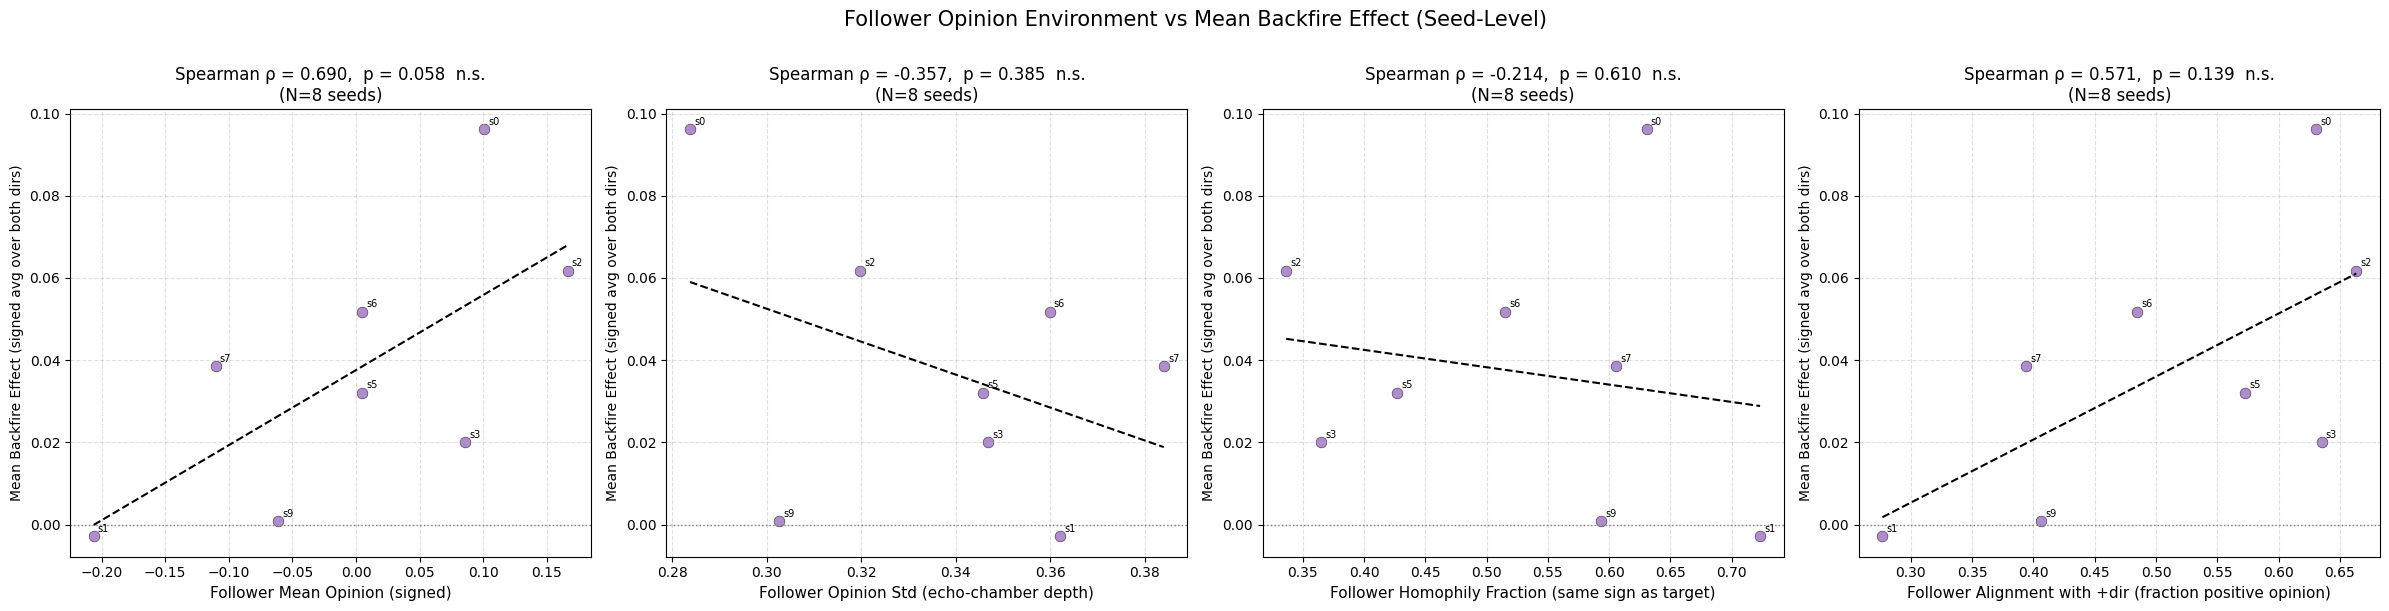

Figure saved to results/summary/BF_analysis/homophily_backfire_seedlevel.png

follower_dir_alignment ~ backfire_effect: per-direction Spearman (run-level)
  dir=-1  N=8  rho=+0.524  p=0.1827  n.s.
  dir=+1  N=8  rho=+0.929  p=0.0009  **


In [6]:
# ---------------------------------------------------------------------------
# Homophily metrics vs mean signed backfire (seed-level).
# ---------------------------------------------------------------------------
HOMOPHILY_METRICS_INVARIANT = [
    ('follower_mean_opinion',   'Follower Mean Opinion (signed)'),
    ('follower_opinion_std',    'Follower Opinion Std (echo-chamber depth)'),
    ('follower_homophily_frac', 'Follower Homophily Fraction (same sign as target)'),
    ('follower_alignment_pos',  'Follower Alignment with +dir (fraction positive opinion)'),
]

df_plot = df_seed.dropna(subset=['mean_backfire'])

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (metric, xlabel) in zip(axes, HOMOPHILY_METRICS_INVARIANT):
    sub = df_plot.dropna(subset=[metric])
    if sub.empty:
        ax.set_title(f"{metric}\n(no data)")
        continue

    x = sub[metric].values
    y = sub['mean_backfire'].values

    ax.scatter(x, y, color='#9467bd', alpha=0.75, s=60, edgecolors='k', linewidths=0.4)

    for _, row in sub.iterrows():
        ax.annotate(f"s{int(row['seed'])}", (row[metric], row['mean_backfire']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 2), textcoords='offset points')

    slope, intercept, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)

    rho, p = stats.spearmanr(x, y)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Mean Backfire Effect (signed avg over both dirs)', fontsize=10)
    ax.set_title(f'Spearman ρ = {rho:.3f},  p = {p:.3f}  {sig}\n(N={len(sub)} seeds)', fontsize=12)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Follower Opinion Environment vs Mean Backfire Effect (Seed-Level)", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, "homophily_backfire_seedlevel.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/summary/BF_analysis/homophily_backfire_seedlevel.png")

# ---------- per-direction Spearman for follower_dir_alignment ----------
# Direction-specific metric: tested per direction on raw run-level df.
print("\nfollower_dir_alignment ~ backfire_effect: per-direction Spearman (run-level)")
df_run_plot = df.dropna(subset=['backfire_effect'])
for sign in [-1.0, 1.0]:
    sub = df_run_plot[df_run_plot['target_sign'] == sign].dropna(subset=['follower_dir_alignment'])
    rho, p = stats.spearmanr(sub['follower_dir_alignment'], sub['backfire_effect'])
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    print(f"  dir={sign:+.0f}  N={len(sub)}  rho={rho:+.3f}  p={p:.4f}  {sig}")

### Section 1 — Additional Analyses: Target Follower Dynamics Around Intervention

Three complementary analyses tracking how the target's follower environment changes around step 20 000 (the intervention point). All use **direction-relative group labels** — opinion bins are mapped relative to the manipulation direction, never hard-coded:

| Label | Meaning | dir = +1 bin | dir = −1 bin |
|---|---|---|---|
| `far_opposite` | Furthest from target direction | 0 | 4 |
| `near_opposite` | Close to opposite side | 1 | 3 |
| `neutral` | Centre | 2 | 2 |
| `near_target` | Close to target direction | 3 | 1 |
| `far_target` | Furthest toward target direction | 4 | 0 |

| # | What is measured | Comparison |
|---|---|---|
| 1 | Follower opinion composition | step 20 000 (pre) vs step 40 000 (post) |
| 2 | Net unfollowing count by class | window 0→20 000 vs 20 000→40 000 |
| 3 | Posting share by class (from post CSV) | steps 19 000–20 000 vs 39 000–40 000 |

Analysis 1: collecting follower opinion distributions ...


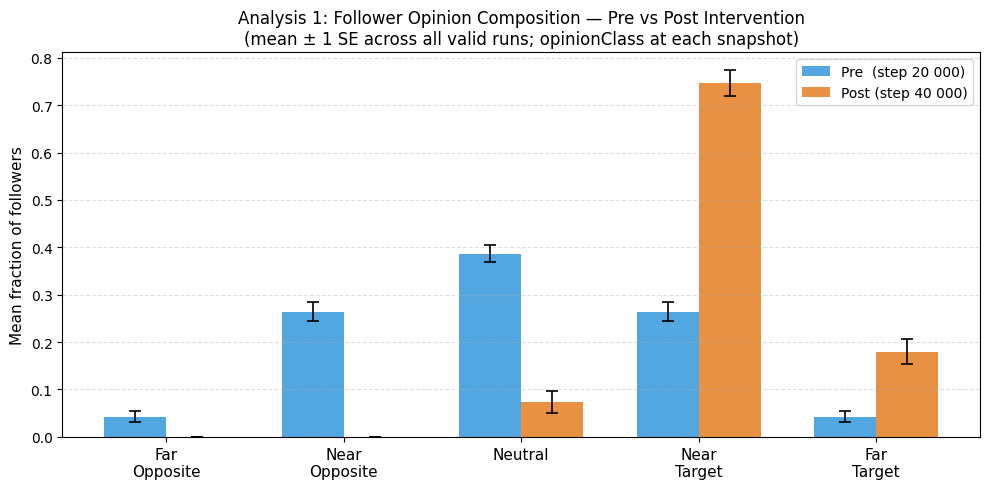

Saved: results/summary/BF_analysis/follower_opinion_dist_change.png

Mean ± SE of follower fraction by group and window:

  pre:
    far_opposite      mean=0.0429  SE=0.0114
    near_opposite     mean=0.2639  SE=0.0199
    neutral           mean=0.3863  SE=0.0183
    near_target       mean=0.2639  SE=0.0199
    far_target        mean=0.0429  SE=0.0114

  post:
    far_opposite      mean=0.0000  SE=0.0000
    near_opposite     mean=0.0000  SE=0.0000
    neutral           mean=0.0732  SE=0.0235
    near_target       mean=0.7468  SE=0.0265
    far_target        mean=0.1800  SE=0.0271


In [7]:
# ---------------------------------------------------------------------------
# Analysis 1: Follower opinion composition — step 20 000 vs step 40 000
# ---------------------------------------------------------------------------
fol_dist_records = []
print('Analysis 1: collecting follower opinion distributions ...')

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m: continue
    seed, target_sign = int(m.group(1)), float(m.group(2))
    if seed not in set(SEEDS): continue

    fp_20k = _gexf_path(run_dir, 20000)
    if not fp_20k: continue
    G_20k, target_ids, agents_20k = _parse_gexf_full(fp_20k)
    if not target_ids or G_20k is None: continue
    tid = target_ids[0]

    for window, G_cur, agents_cur in [('pre', G_20k, agents_20k), ('post', None, None)]:
        if window == 'post':
            fp = _gexf_path(run_dir, 40000)
            if not fp: continue
            G_cur, _, agents_cur = _parse_gexf_full(fp)
            if G_cur is None or tid not in G_cur: continue

        followers = list(G_cur.predecessors(tid)) if tid in G_cur else []
        counts = {g: 0 for g in GROUP_ORDER}
        total = 0
        for f in followers:
            oc = agents_cur.get(f, {}).get('opinionclass', -1)
            if oc not in range(5): continue
            grp = _POS_MAP[target_sign].get(oc, 'unknown')
            if grp in counts:
                counts[grp] += 1
                total += 1
        for grp in GROUP_ORDER:
            fol_dist_records.append({
                'seed': seed, 'target_sign': target_sign, 'window': window,
                'relative_group': grp,
                'fraction': counts[grp] / total if total > 0 else np.nan,
            })

df_fol_dist = pd.DataFrame(fol_dist_records)
_gb_fd = df_fol_dist.groupby(['window', 'relative_group'])['fraction']
pivot_fd    = _gb_fd.mean().unstack('relative_group')[GROUP_ORDER]
pivot_fd_se = _gb_fd.sem() .unstack('relative_group')[GROUP_ORDER]

_ekw = dict(elinewidth=1.2, ecolor='k', capthick=1.2)
x = np.arange(len(GROUP_ORDER))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, pivot_fd.loc['pre'].values,  w,
       yerr=pivot_fd_se.loc['pre'].values,  capsize=4, error_kw=_ekw,
       label='Pre  (step 20 000)', color='#3498db', alpha=0.85)
ax.bar(x + w/2, pivot_fd.loc['post'].values, w,
       yerr=pivot_fd_se.loc['post'].values, capsize=4, error_kw=_ekw,
       label='Post (step 40 000)', color='#e67e22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, fontsize=11)
ax.set_ylabel('Mean fraction of followers', fontsize=11)
ax.set_title(
    'Analysis 1: Follower Opinion Composition — Pre vs Post Intervention\n'
    '(mean \u00b1 1 SE across all valid runs; opinionClass at each snapshot)',
    fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'summary', 'follower_opinion_dist_change.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: results/summary/BF_analysis/follower_opinion_dist_change.png')
print('\nMean \u00b1 SE of follower fraction by group and window:')
for win in ['pre', 'post']:
    print(f'\n  {win}:')
    for grp in GROUP_ORDER:
        print(f'    {grp:16s}  mean={pivot_fd.loc[win, grp]:.4f}  SE={pivot_fd_se.loc[win, grp]:.4f}')


Analysis 2: collecting unfollow counts ...


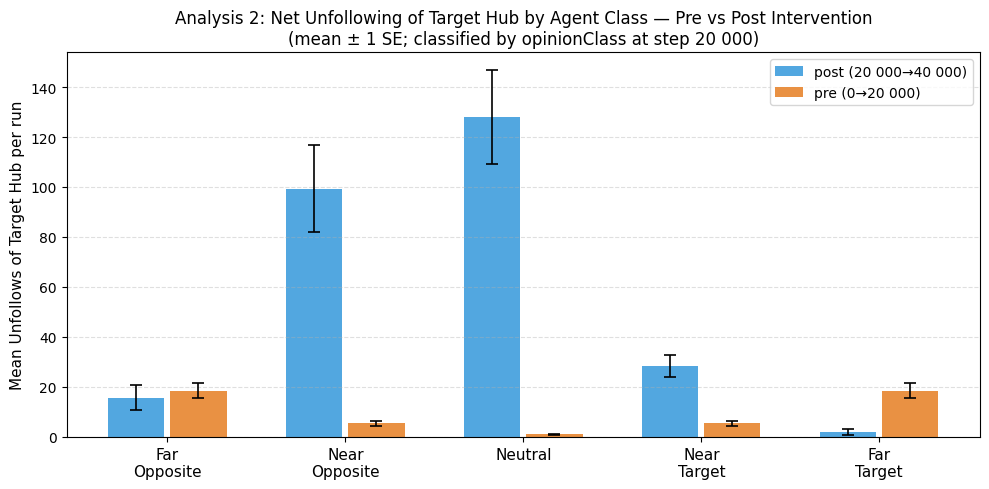

Saved: results/summary/BF_analysis/unfollow_count_by_class.png

Mean ± SE of unfollows of Target Hub per run by group and window:

  post (20 000→40 000):
    far_opposite      mean=15.69  SE=4.97
    near_opposite     mean=99.38  SE=17.46
    neutral           mean=127.88  SE=18.76
    near_target       mean=28.38  SE=4.57
    far_target        mean=1.88  SE=1.20

  pre (0→20 000):
    far_opposite      mean=18.50  SE=3.02
    near_opposite     mean=5.38  SE=0.98
    neutral           mean=1.00  SE=0.29
    near_target       mean=5.38  SE=0.98
    far_target        mean=18.50  SE=3.02


In [8]:
# ---------------------------------------------------------------------------
# Analysis 2: Net unfollowing count by class
#   pre  = agents who followed at step 0 but NOT at step 20 000
#   post = agents who followed at step 20 000 but NOT at step 40 000
# Comparison windows (0-20 000 vs 20 000-40 000) are equal-length for fair
# comparison.  Unfollowers are classified by their opinionClass at step 20 000
# (the last pre-intervention snapshot) mapped to direction-relative groups.
# ---------------------------------------------------------------------------
unfollow_records = []
print('Analysis 2: collecting unfollow counts ...')

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m: continue
    seed, target_sign = int(m.group(1)), float(m.group(2))
    if seed not in set(SEEDS): continue

    fp_20k = _gexf_path(run_dir, 20000)
    if not fp_20k: continue
    G_20k, target_ids, agents_20k = _parse_gexf_full(fp_20k)
    if not target_ids or G_20k is None: continue
    tid = target_ids[0]

    def _cls(nid):
        oc = agents_20k.get(nid, {}).get('opinionclass', -1)
        return _POS_MAP[target_sign].get(oc, 'unknown') if oc in range(5) else 'unknown'

    fol_20k = set(G_20k.predecessors(tid)) if tid in G_20k else set()

    fp_0 = _gexf_path(run_dir, 0)
    fol_0 = set()
    if fp_0:
        G_0, _, _ = _parse_gexf_full(fp_0)
        if G_0 is not None and tid in G_0:
            fol_0 = set(G_0.predecessors(tid))

    fp_40k = _gexf_path(run_dir, 40000)
    fol_40k = set()
    if fp_40k:
        G_40k, _, _ = _parse_gexf_full(fp_40k)
        if G_40k is not None and tid in G_40k:
            fol_40k = set(G_40k.predecessors(tid))

    for window, unfol in [('pre (0→20 000)',        fol_0   - fol_20k),
                           ('post (20 000→40 000)',  fol_20k - fol_40k)]:
        counts = {g: 0 for g in GROUP_ORDER}
        for nid in unfol:
            grp = _cls(nid)
            if grp in counts:
                counts[grp] += 1
        for grp in GROUP_ORDER:
            unfollow_records.append({
                'seed': seed, 'target_sign': target_sign,
                'window': window, 'relative_group': grp, 'count': counts[grp],
            })

df_unfollow = pd.DataFrame(unfollow_records)
_gb_uf = df_unfollow.groupby(['window', 'relative_group'])['count']
pivot_uf    = _gb_uf.mean().unstack('relative_group')[GROUP_ORDER]
pivot_uf_se = _gb_uf.sem() .unstack('relative_group')[GROUP_ORDER]

_ekw = dict(elinewidth=1.2, ecolor='k', capthick=1.2)
x = np.arange(len(GROUP_ORDER))
windows_uf = list(pivot_uf.index)
width = 0.7 / len(windows_uf)
colors_uf = ['#3498db', '#e67e22']

fig, ax = plt.subplots(figsize=(10, 5))
for wi, (win, color) in enumerate(zip(windows_uf, colors_uf)):
    offset = (wi - (len(windows_uf) - 1) / 2) * width
    ax.bar(x + offset, pivot_uf.loc[win].values, width * 0.9,
           yerr=pivot_uf_se.loc[win].values, capsize=4, error_kw=_ekw,
           label=win, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, fontsize=11)
ax.set_ylabel('Mean Unfollows of Target Hub per run', fontsize=11)
ax.set_title(
    'Analysis 2: Net Unfollowing of Target Hub by Agent Class — Pre vs Post Intervention\n'
    '(mean \u00b1 1 SE; classified by opinionClass at step 20 000)',
    fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'summary', 'unfollow_count_by_class.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: results/summary/BF_analysis/unfollow_count_by_class.png')
print('\nMean \u00b1 SE of unfollows of Target Hub per run by group and window:')
for win in windows_uf:
    print(f'\n  {win}:')
    for grp in GROUP_ORDER:
        print(f'    {grp:16s}  mean={pivot_uf.loc[win, grp]:.2f}  SE={pivot_uf_se.loc[win, grp]:.2f}')


Analysis 2b: collecting target hub unfollow timeseries ...


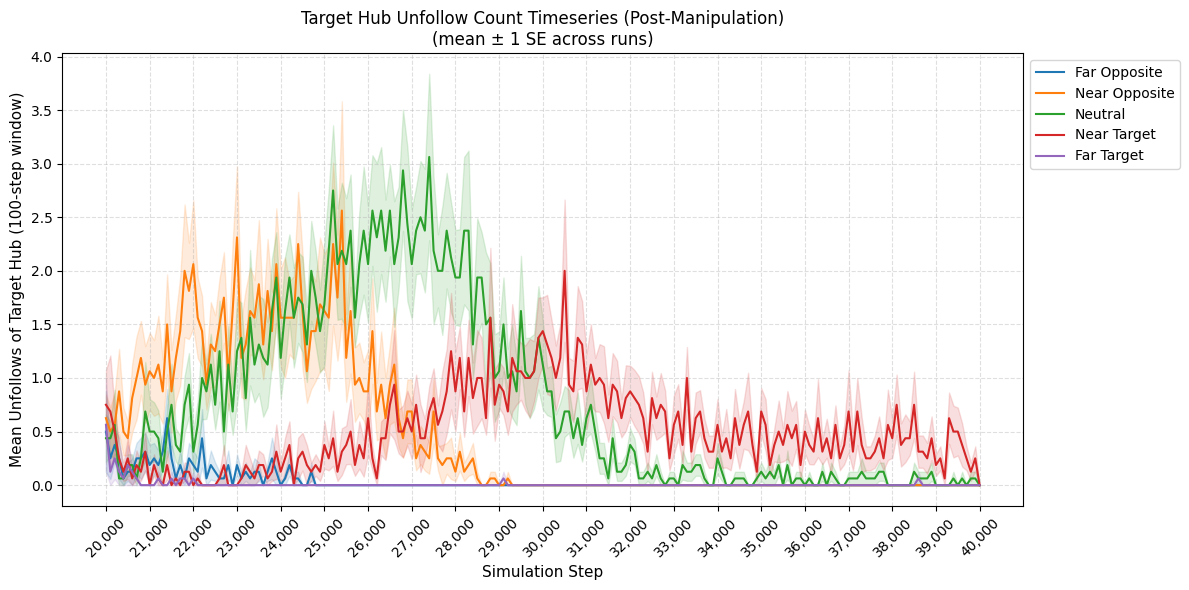

Saved: results/summary/BF_analysis/unfollow_timeseries_post.png


In [9]:
# ---------------------------------------------------------------------------
# Analysis 2b: Target hub unfollow timeseries (100-step windows)
# ---------------------------------------------------------------------------
print('Analysis 2b: collecting target hub unfollow timeseries ...')
unfollow_ts_records = []
for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m: continue
    seed, target_sign = int(m.group(1)), float(m.group(2))
    if seed not in set(SEEDS): continue

    df_ts = load_unfollow_timeseries_local(run_dir, target_sign)
    if df_ts is not None:
        df_ts.insert(0, 'target_sign', target_sign)
        df_ts.insert(0, 'seed', seed)
        unfollow_ts_records.append(df_ts)

if unfollow_ts_records:
    df_uf_ts = pd.concat(unfollow_ts_records, ignore_index=True)
    
    # Filter to show only post-manipulation period (step >= 20000)
    df_uf_ts = df_uf_ts[df_uf_ts['step'] >= 20000]
    
    # Aggregate across runs
    ts_mean = df_uf_ts.groupby('step')[GROUP_ORDER].mean()
    ts_se = df_uf_ts.groupby('step')[GROUP_ORDER].sem()
    
    steps = ts_mean.index
    
    fig, ax = plt.subplots(figsize=(12, 6))
    for grp in GROUP_ORDER:
        mean_val = ts_mean[grp]
        se_val = ts_se[grp]
        line, = ax.plot(steps, mean_val, label=grp.replace('_', ' ').title())
        ax.fill_between(steps, mean_val - se_val, mean_val + se_val, alpha=0.15, color=line.get_color())
    
    ax.set_xlabel('Simulation Step', fontsize=11)
    ax.set_ylabel('Mean Unfollows of Target Hub (100-step window)', fontsize=11)
    ax.set_title('Target Hub Unfollow Count Timeseries (Post-Manipulation)\n(mean ± 1 SE across runs)', fontsize=12)
    
    # Finer x-ticks: every 1000 steps
    tick_step = 1000
    if not steps.empty:
        xticks = np.arange(20000, steps.max() + tick_step, tick_step)
        ax.set_xticks(xticks)
        ax.set_xticklabels([f"{int(x):,}" for x in xticks], rotation=45)
    
    ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'summary', 'unfollow_timeseries_post.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: results/summary/BF_analysis/unfollow_timeseries_post.png')
else:
    print('No target hub unfollow timeseries data found.')

### Analysis 2c & 2d: Dynamic Proxies for Opinion Shift and Comfort

To track the high-resolution (100-step) dynamics of agent states, we use metrics recorded in the `metrics/result_*.csv` files. Note that agents are grouped into direction-relative classes based on their **current** `opinionClass` at each step.

1. **cRate (Comfort Rate)**: Average comfort rate per class. Measures how well agents' opinions align with their local social environment.
2. **Directional Opinion Shift**: Calculated as the 100-step difference in **Feed Opinion Mean** (`feedPostOpinionMean`) adjusted by `target_sign`. This serves as a proxy for the driving force behind internal opinion change. A **positive** value indicates a shift towards the target direction, while a **negative** value indicates a shift towards the opposite direction.

Analysis 2c & 2d: collecting cRate and population shift data ...


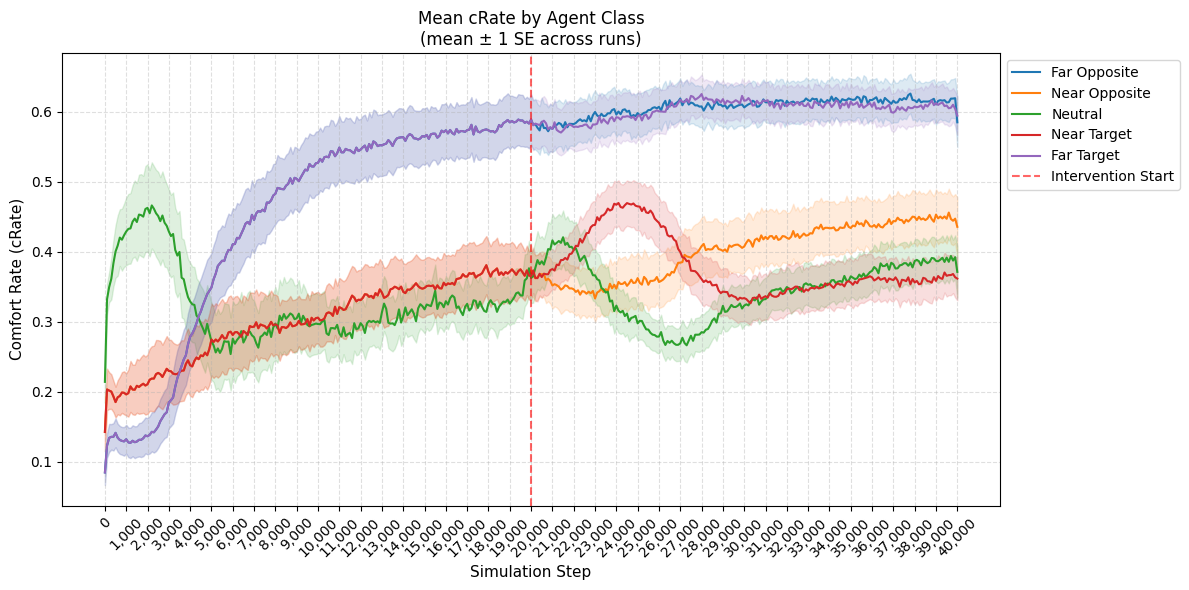

Saved: results/summary/BF_analysis/crate_timeseries.png


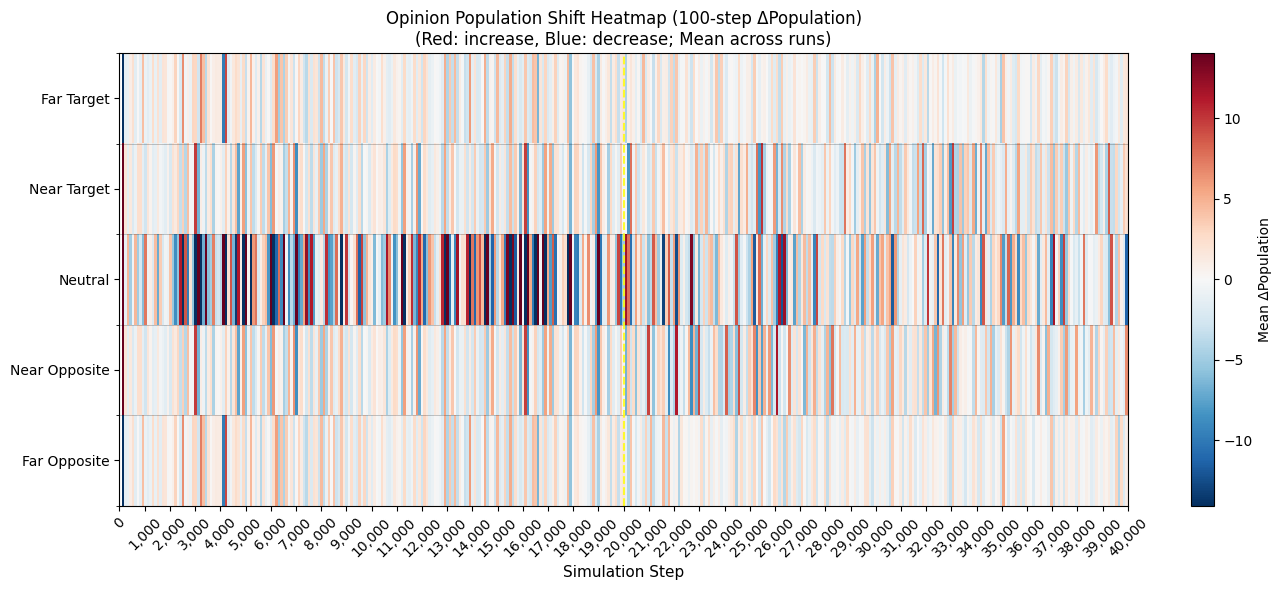

Saved: results/summary/BF_analysis/opinion_population_shift_heatmap.png


In [10]:
# ---------------------------------------------------------------------------
# Analysis 2c & 2d: cRate and Opinion Population Shift Heatmap (Blocky)
# ---------------------------------------------------------------------------
def load_metric_timeseries(run_dir, target_sign, prefix, window=100):
    metric_dir = os.path.join(run_dir, "metrics")
    files = glob.glob(os.path.join(metric_dir, "result_*.csv"))
    if not files: return None
    dfs = [pd.read_csv(f) for f in files]
    df = pd.concat(dfs).sort_values("step").reset_index(drop=True)

    pmap = _POS_MAP[target_sign]
    res_df = pd.DataFrame({"step": df["step"]})
    # Initialize GROUP_ORDER columns to NaN
    for g in GROUP_ORDER:
        res_df[g] = np.nan

    for i in range(5):
        col = f"{prefix}_{i}"
        if col in df.columns:
            group = pmap[i]
            res_df[group] = df[col]
    
    res_df["window_idx"] = res_df["step"] // window
    agg = res_df.groupby("window_idx")[GROUP_ORDER].mean()
    agg["step"] = agg.index * window
    return agg.reset_index(drop=True)

print("Analysis 2c & 2d: collecting cRate and population shift data ...")
crate_records = []
op_change_records = []

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r"run_(\d+)_dir_([+-]?\d+\.?\d*)", dirname)
    if not m: continue
    seed, target_sign = int(m.group(1)), float(m.group(2))
    if seed not in SEEDS: continue

    df_c = load_metric_timeseries(run_dir, target_sign, "cRateMean")
    if df_c is not None:
        df_c.insert(0, "target_sign", target_sign)
        df_c.insert(0, "seed", seed)
        crate_records.append(df_c)
    
    metric_dir = os.path.join(run_dir, "opinion")
    files = glob.glob(os.path.join(metric_dir, "opinion_result_*.csv"))
    if files:
        dfs = [pd.read_csv(f) for f in files]
        df_pop = pd.concat(dfs).sort_values("step").reset_index(drop=True)
        # Sample every 100 steps to ensure rectangles are visible
        df_pop = df_pop[df_pop["step"] % 100 == 0].reset_index(drop=True)
        if target_sign > 0:
            mapping = {"bin_4": "R0", "bin_3": "R1", "bin_2": "R2", "bin_1": "R3", "bin_0": "R4"}
        else:
            mapping = {"bin_0": "R0", "bin_1": "R1", "bin_2": "R2", "bin_3": "R3", "bin_4": "R4"}
        df_pop_diff = df_pop[list(mapping.keys())].diff()
        df_pop_diff = df_pop_diff.rename(columns=mapping)
        df_pop_diff.insert(0, "step", df_pop["step"])
        df_pop_diff.insert(0, "target_sign", target_sign)
        df_pop_diff.insert(0, "seed", seed)
        op_change_records.append(df_pop_diff)

def plot_ts(records, title, ylabel, filename):
    if not records: return
    df_all = pd.concat(records, ignore_index=True)
    ts_mean = df_all.groupby("step")[GROUP_ORDER].mean()
    ts_se = df_all.groupby("step")[GROUP_ORDER].sem()
    steps = ts_mean.index
    fig, ax = plt.subplots(figsize=(12, 6))
    for grp in GROUP_ORDER:
        m, s = ts_mean[grp], ts_se[grp]
        line, = ax.plot(steps, m, label=grp.replace("_", " ").title())
        ax.fill_between(steps, m - s, m + s, alpha=0.15, color=line.get_color())
    ax.axvline(20000, color="red", linestyle="--", alpha=0.6, label="Intervention Start")
    ax.set_xlabel("Simulation Step", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    tick_step = 1000
    xticks = np.arange(0, steps.max() + tick_step, tick_step)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{int(x):,}" for x in xticks], rotation=45)
    ax.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1, 1))
    ax.grid(linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(SUMMARY_DIR, filename), dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: results/summary/BF_analysis/{filename}")

def plot_pop_shift_heatmap(records, filename):
    if not records: return
    df_all = pd.concat(records, ignore_index=True)
    rcols = ["R0", "R1", "R2", "R3", "R4"]
    ts_mean = df_all.groupby("step")[rcols].mean().sort_index()
    data = ts_mean.values.T
    steps = ts_mean.index
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    abs_data = np.abs(data[~np.isnan(data)])
    limit = np.percentile(abs_data, 95) * 1.5 if len(abs_data) > 0 else 1.0
    
    # Use interpolation="nearest" to get distinct rectangular blocks
    im = ax.imshow(data, aspect="auto", cmap="RdBu_r", 
                   extent=[steps.min(), steps.max(), 4.5, -0.5], 
                   vmin=-limit, vmax=limit, interpolation="nearest")
    
    ax.set_yticks(range(5))
    ax.set_yticklabels(["Far Target", "Near Target", "Neutral", "Near Opposite", "Far Opposite"])
    
    # Add grid lines between cells to make boundaries explicit
    ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5, alpha=0.3)
    
    ax.set_xlabel("Simulation Step", fontsize=11)
    ax.set_title("Opinion Population Shift Heatmap (100-step ΔPopulation)\n" 
                 "(Red: increase, Blue: decrease; Mean across runs)", fontsize=12)
    ax.axvline(20000, color="yellow", linestyle="--", alpha=0.8, label="Intervention Start")
    
    tick_step = 1000
    xticks = np.arange(0, steps.max() + tick_step, tick_step)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{int(x):,}" for x in xticks], rotation=45)
    
    plt.colorbar(im, label="Mean ΔPopulation")
    plt.tight_layout()
    plt.savefig(os.path.join(SUMMARY_DIR, filename), dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: results/summary/BF_analysis/{filename}")

plot_ts(crate_records, "Mean cRate by Agent Class\n(mean ± 1 SE across runs)", "Comfort Rate (cRate)", "crate_timeseries.png")
plot_pop_shift_heatmap(op_change_records, "opinion_population_shift_heatmap.png")


### Analysis 2e: Unified Dynamics (Unfollow Count vs. Mean cRate)

This plot aligns the **Target Hub Unfollow Count** and the **Mean cRate** (Comfort Rate) over the entire simulation period (0 to 40,000 steps). 

*   **Top Panel**: Target Hub Unfollow Count (Sum in 100-step windows). Vertical red line marks the start of manipulation at step 20,000.
*   **Bottom Panel**: Mean cRate per agent class. Low cRate indicates agents are uncomfortable with their feed opinions relative to their own.

Aligned timesteps allow for direct comparison of when structural changes (unfollowing) coincide with shifts in social comfort.

Analysis 2e: Generating unified dynamics plot...


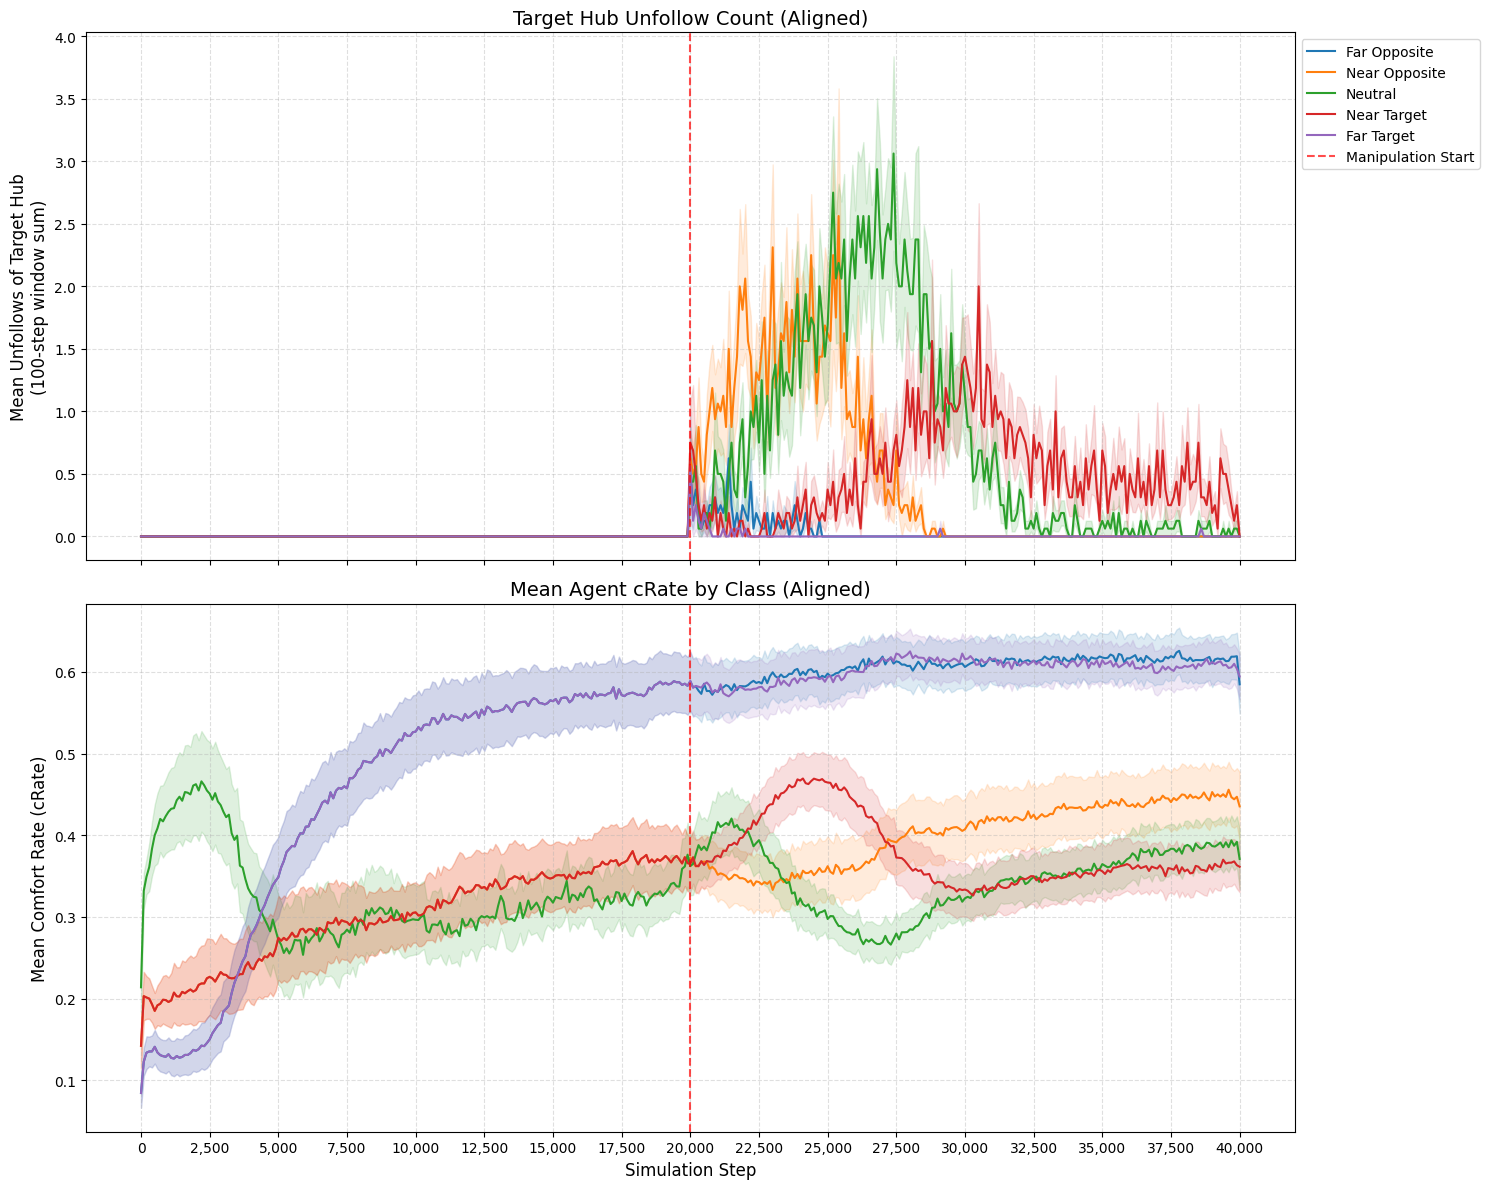

Unified dynamics plot saved to ./results/BF_analysis/unified_unfollow_crate_dynamics.png


In [11]:
# ---------------------------------------------------------------------------
# Analysis 2e: Aligned Unfollow and cRate Timeseries (0-40,000 steps)
# ---------------------------------------------------------------------------
print('Analysis 2e: Generating unified dynamics plot...')

# 1. Collect Data
uf_records = []
cr_records = []

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m: continue
    seed, target_sign = int(m.group(1)), float(m.group(2))
    if seed not in set(SEEDS): continue

    # Unfollow TS
    df_uf = load_unfollow_timeseries_local(run_dir, target_sign)
    if df_uf is not None:
        df_uf.insert(0, 'target_sign', target_sign)
        df_uf.insert(0, 'seed', seed)
        uf_records.append(df_uf)

    # cRate TS
    df_cr = load_metric_timeseries(run_dir, target_sign, "cRateMean")
    if df_cr is not None:
        df_cr.insert(0, 'target_sign', target_sign)
        df_cr.insert(0, 'seed', seed)
        cr_records.append(df_cr)

if uf_records and cr_records:
    df_uf_all = pd.concat(uf_records, ignore_index=True)
    df_cr_all = pd.concat(cr_records, ignore_index=True)

    # Aggregate
    uf_mean = df_uf_all.groupby('step')[GROUP_ORDER].mean()
    uf_se   = df_uf_all.groupby('step')[GROUP_ORDER].sem()
    cr_mean = df_cr_all.groupby('step')[GROUP_ORDER].mean()
    cr_se   = df_cr_all.groupby('step')[GROUP_ORDER].sem()

    steps = uf_mean.index

    # 2. Plotting
    fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
    
    # Colors for consistency
    colors = plt.cm.viridis(np.linspace(0, 1, len(GROUP_ORDER)))

    # Top: Unfollow Count
    ax0 = axes[0]
    for i, grp in enumerate(GROUP_ORDER):
        m, s = uf_mean[grp], uf_se[grp]
        line, = ax0.plot(m.index, m, label=grp.replace('_', ' ').title())
        ax0.fill_between(m.index, m - s, m + s, alpha=0.15, color=line.get_color())
    
    ax0.axvline(20000, color='red', linestyle='--', alpha=0.7, label='Manipulation Start')
    ax0.set_ylabel('Mean Unfollows of Target Hub\n(100-step window sum)', fontsize=12)
    ax0.set_title('Target Hub Unfollow Count (Aligned)', fontsize=14)
    ax0.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    ax0.grid(linestyle='--', alpha=0.4)

    # Bottom: cRate
    ax1 = axes[1]
    for i, grp in enumerate(GROUP_ORDER):
        m, s = cr_mean[grp], cr_se[grp]
        line, = ax1.plot(m.index, m, label=grp.replace('_', ' ').title())
        ax1.fill_between(m.index, m - s, m + s, alpha=0.15, color=line.get_color())

    ax1.axvline(20000, color='red', linestyle='--', alpha=0.7)
    ax1.set_xlabel('Simulation Step', fontsize=12)
    ax1.set_ylabel('Mean Comfort Rate (cRate)', fontsize=12)
    ax1.set_title('Mean Agent cRate by Class (Aligned)', fontsize=14)
    ax1.grid(linestyle='--', alpha=0.4)

    # Adjust ticks
    tick_step = 2500
    xticks = np.arange(0, 40001, tick_step)
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f"{int(x):,}" for x in xticks])

    plt.tight_layout()
    save_path = os.path.join(SUMMARY_DIR, 'unified_unfollow_crate_dynamics.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Unified dynamics plot saved to {save_path}')
else:
    print('Could not find enough data for unified dynamics plot.')


In [12]:
# ---------------------------------------------------------------------------
# Classify seeds by backfire robustness
# ---------------------------------------------------------------------------
paired = {}
for _, row in df.iterrows():
    seed = row['seed']
    if seed not in paired:
        paired[seed] = {}
    paired[seed][row['target_sign']] = row

seed_class = {s: classify_seed(d) for s, d in paired.items() if classify_seed(d) is not None}
print("Seed classification:")
for label in ['both', 'one', 'neither']:
    seeds = [s for s, c in seed_class.items() if c == label]
    print(f"  {label:8s}: {len(seeds)} seeds")

# Build seed-level summary frame
df_seeds = pd.DataFrame([make_seed_row(s, paired[s], seed_class)
                         for s in seed_class if seed_class[s] is not None])
print(f"\nSeed-level frame: {len(df_seeds)} rows")
print(df_seeds.groupby('backfire_class')['in_degree'].describe()[['count', '50%', 'mean', 'std']])

Seed classification:
  both    : 3 seeds
  one     : 5 seeds
  neither : 0 seeds

Seed-level frame: 8 rows
                count    50%   mean         std
backfire_class                                 
both              3.0  592.0  480.0  225.884926
one               5.0  195.0  302.0  218.206324


In [13]:
# ---------------------------------------------------------------------------
# Build per-agent delta dataframe across all valid runs
# ---------------------------------------------------------------------------
PRE_STEPS  = [10000, 15000, 20000]   # average window before manipulation
POST_STEPS = [20000, 25000, 30000]   # average window after manipulation starts

agent_records = []
for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m: continue
    seed, target_sign = int(m.group(1)), float(m.group(2))
    if seed not in SEEDS: continue
    if seed not in seed_class: continue
    
    bclass = seed_class[seed]
    print(f"  {dirname}  [{bclass}] ...", end=" ")
    
    rows = compute_run_agent_deltas(run_dir, PRE_STEPS, POST_STEPS)
    if not rows:
        print("no data")
        continue
    
    for r in rows:
        r.update({
            'seed':           seed,
            'run_id':         dirname,
            'target_sign':    target_sign,
            'backfire_class': bclass,
            'relative_group': get_relative_group(r['opinionclass'], target_sign),
        })
    agent_records.extend(rows)
    print(f"{len(rows)} agents")

df_agents = pd.DataFrame(agent_records)
df_agents = df_agents[df_agents['opinionclass'].between(0, 4)]
print(f"\nTotal agent-run records: {len(df_agents)}")

print("\nMedian Δ by backfire class × relative group:")
print(df_agents.groupby(["backfire_class", "relative_group"])
    [["delta_opinion", "delta_postprob"]].median().round(4))


  run_0_dir_-1.0  [both] ... 999 agents
  run_0_dir_1.0  [both] ... 999 agents
  run_1_dir_-1.0  [one] ... 999 agents
  run_1_dir_1.0  [one] ... 999 agents
  run_2_dir_-1.0  [one] ... 999 agents
  run_2_dir_1.0  [one] ... 999 agents
  run_3_dir_-1.0  [one] ... 999 agents
  run_3_dir_1.0  [one] ... 999 agents
  run_5_dir_-1.0  [both] ... 999 agents
  run_5_dir_1.0  [both] ... 999 agents
  run_6_dir_-1.0  [both] ... 999 agents
  run_6_dir_1.0  [both] ... 999 agents
  run_7_dir_-1.0  [one] ... 999 agents
  run_7_dir_1.0  [one] ... 999 agents
  run_9_dir_-1.0  [one] ... 999 agents
  run_9_dir_1.0  [one] ... 999 agents

Total agent-run records: 15984

Median Δ by backfire class × relative group:
                               delta_opinion  delta_postprob
backfire_class relative_group                               
both           far_opposite           0.0000             0.0
               far_target             0.0000             0.0
               near_opposite          0.0000            

Analysis 3: counting agents with increased posting prob by class ...


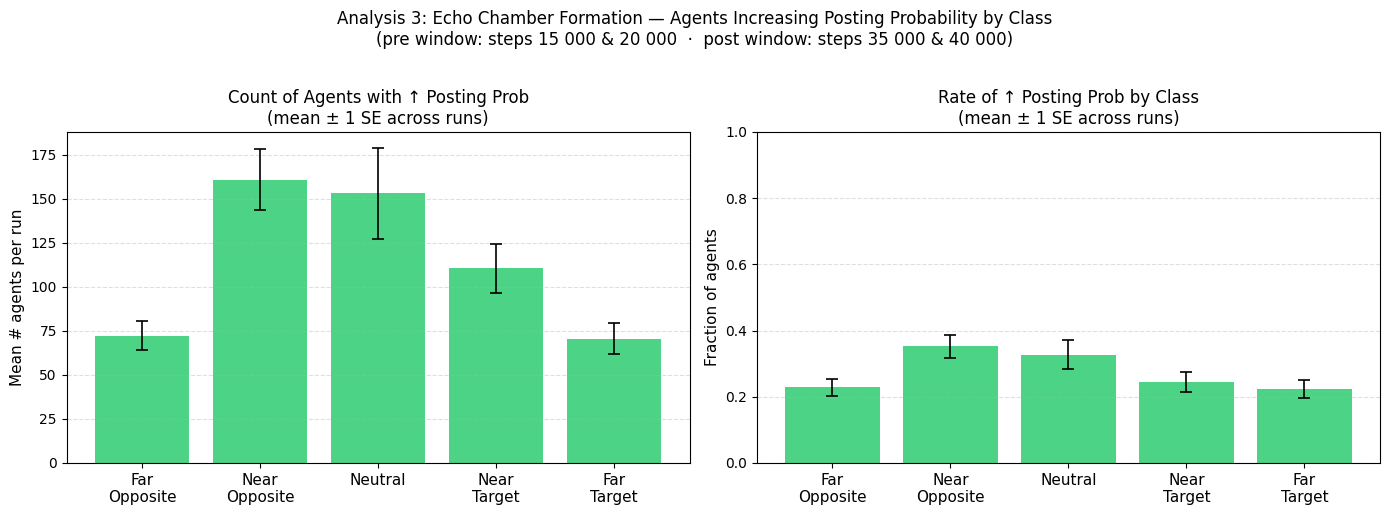

Saved: results/summary/BF_analysis/posting_prob_increase_by_class.png

Mean ± SE — agents increasing posting prob by relative group:
  far_opposite      count=72.1 ± 8.22  rate=0.2280 ± 0.0257
  near_opposite     count=160.6 ± 17.29  rate=0.3526 ± 0.0351
  neutral           count=153.0 ± 25.92  rate=0.3264 ± 0.0442
  near_target       count=110.4 ± 13.92  rate=0.2434 ± 0.0302
  far_target        count=70.5 ± 8.86  rate=0.2227 ± 0.0276


In [14]:
# ---------------------------------------------------------------------------
# Analysis 3: Echo Chamber Formation — Agents Increasing Posting Probability
#             by direction-relative class, around manipulation step 20 000
#
# For each non-target agent, windowed-average postprob is computed:
#   pre  window: steps 15 000 & 20 000  (nearest snapshots before/at intervention)
#   post window: steps 35 000 & 40 000  (nearest snapshots near simulation end)
# An agent "increases" if post_window_avg > pre_window_avg.
# Counts and rates of such agents are tallied per direction-relative class,
# then averaged across runs with ±1 SE.
# ---------------------------------------------------------------------------
_A3_PRE_STEPS  = [15000, 20000]
_A3_POST_STEPS = [35000, 40000]

a3_records = []
print('Analysis 3: counting agents with increased posting prob by class ...')

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m: continue
    seed, target_sign = int(m.group(1)), float(m.group(2))
    if seed not in set(SEEDS): continue

    rows = compute_run_agent_deltas(run_dir, _A3_PRE_STEPS, _A3_POST_STEPS,
                                    class_ref_step=15000, target_ref_step=20000)
    if not rows: continue

    for r in rows:
        grp = _POS_MAP[target_sign].get(r['opinionclass'], 'unknown')
        if grp not in GROUP_ORDER: continue
        a3_records.append({
            'seed':           seed,
            'target_sign':    target_sign,
            'relative_group': grp,
            'pre_postprob':   r['pre_postprob'],
            'post_postprob':  r['post_postprob'],
            'increased':      int(r['post_postprob'] > r['pre_postprob']),
        })

df_a3 = pd.DataFrame(a3_records)

# Per-run x class: count and rate of agents increasing postprob
a3_run_grp = df_a3.groupby(['seed', 'relative_group'])
a3_count   = a3_run_grp['increased'].sum().rename('n_increased')
a3_total   = a3_run_grp['increased'].count().rename('n_total')
a3_rate    = (a3_count / a3_total).rename('rate')
df_a3_run  = pd.concat([a3_count, a3_total, a3_rate], axis=1).reset_index()
df_a3_run  = df_a3_run[df_a3_run['relative_group'].isin(GROUP_ORDER)]

# Aggregate across runs
agg_count    = df_a3_run.groupby('relative_group')['n_increased']
agg_rate     = df_a3_run.groupby('relative_group')['rate']
pivot_cnt    = agg_count.mean().reindex(GROUP_ORDER)
pivot_cnt_se = agg_count.sem() .reindex(GROUP_ORDER)
pivot_rate   = agg_rate.mean() .reindex(GROUP_ORDER)
pivot_rate_se= agg_rate.sem()  .reindex(GROUP_ORDER)

_ekw  = dict(elinewidth=1.2, ecolor='k', capthick=1.2)
x     = np.arange(len(GROUP_ORDER))
color = '#2ecc71'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(x, pivot_cnt.values, yerr=pivot_cnt_se.values, capsize=4,
       error_kw=_ekw, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, fontsize=11)
ax.set_ylabel('Mean # agents per run', fontsize=11)
ax.set_title('Count of Agents with ↑ Posting Prob\n(mean ± 1 SE across runs)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[1]
ax.bar(x, pivot_rate.values, yerr=pivot_rate_se.values, capsize=4,
       error_kw=_ekw, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, fontsize=11)
ax.set_ylabel('Fraction of agents', fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Rate of ↑ Posting Prob by Class\n(mean ± 1 SE across runs)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(
    'Analysis 3: Echo Chamber Formation — Agents Increasing Posting Probability by Class\n'
    '(pre window: steps 15 000 & 20 000  ·  post window: steps 35 000 & 40 000)',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'summary', 'posting_prob_increase_by_class.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: results/summary/BF_analysis/posting_prob_increase_by_class.png')

print('\nMean ± SE — agents increasing posting prob by relative group:')
for grp in GROUP_ORDER:
    print(f'  {grp:16s}  count={pivot_cnt[grp]:.1f} ± {pivot_cnt_se[grp]:.2f}'
          f'  rate={pivot_rate[grp]:.4f} ± {pivot_rate_se[grp]:.4f}')

---
## Section 2: Classification by Backfire Direction (Both / One / Neither)

We classify each seed by whether backfire occurs in *both*, *one*, or *neither* manipulation direction.

**"Both-direction backfire" is theoretically the cleanest signal**: it is invariant to the direction-of-manipulation confound. A target that generates counter-mobilisation regardless of which way it is pushed must possess some structural property that guarantees the reaction — independent of the opinion asymmetry in the broader network.

We compare structural metrics between the **both** group and the **rest** using Mann-Whitney U (distribution-free) and the rank-biserial correlation *r* as effect size.

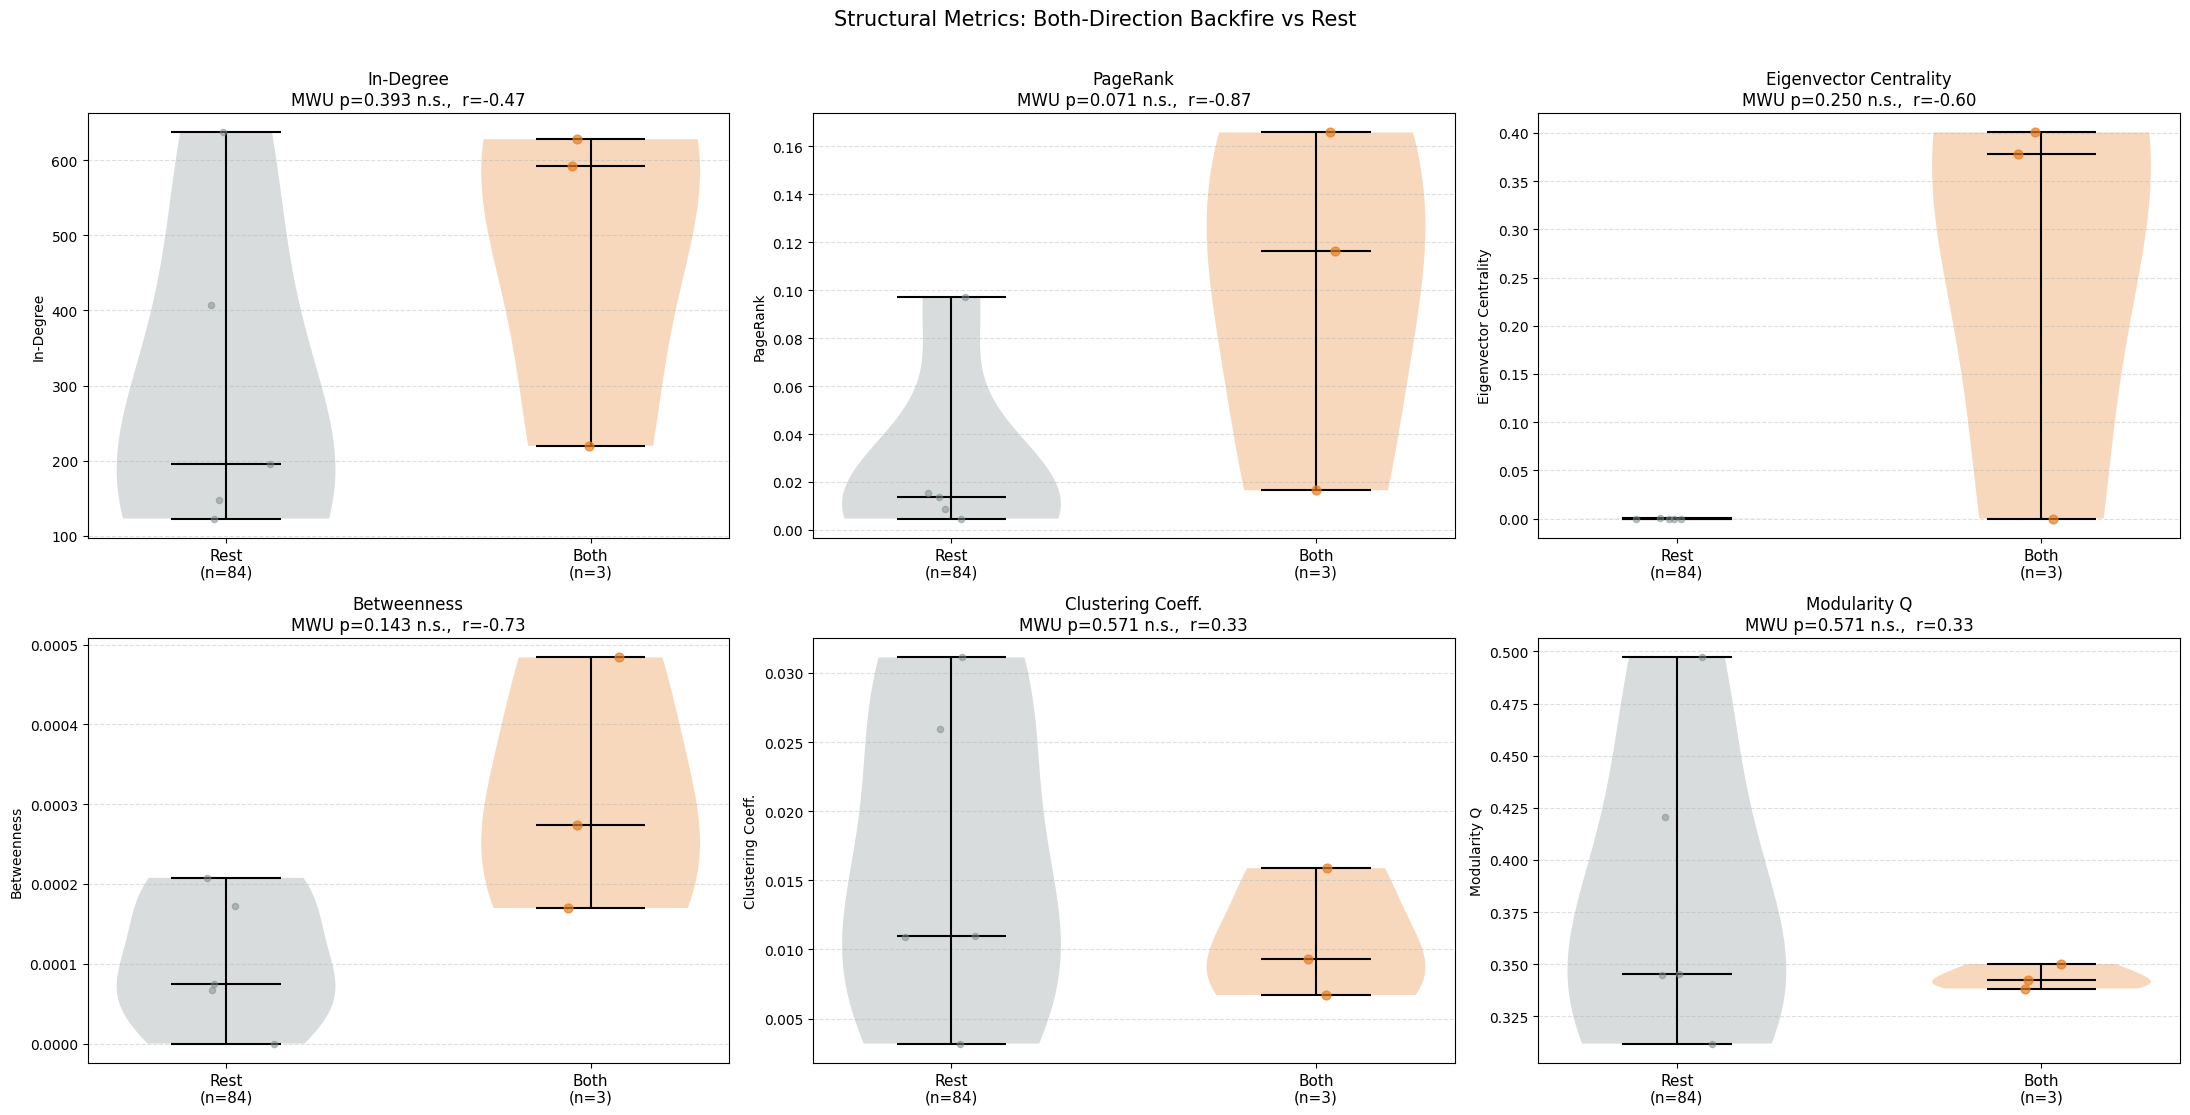

Saved: results/summary/BF_analysis/both_backfire_structure.png


In [15]:
# ---------------------------------------------------------------------------
# Fig 1: Structural metric distributions — both vs rest (violin + strip)
# ---------------------------------------------------------------------------
from scipy import stats as sp_stats

both_df = df_seeds[df_seeds['backfire_class'] == 'both']
rest_df = df_seeds[df_seeds['backfire_class'] != 'both']

METRICS_COMPARE = [
    ('in_degree',   'In-Degree'),
    ('pagerank',    'PageRank'),
    ('eigenvector', 'Eigenvector Centrality'),
    ('betweenness', 'Betweenness'),
    ('clustering',  'Clustering Coeff.'),
    ('modularity',  'Modularity Q'),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 11))
axes = axes.flatten()
palette = {'both': '#e67e22', 'rest': '#7f8c8d'}

for ax, (metric, label) in zip(axes, METRICS_COMPARE):
    a = both_df[metric].dropna().values
    b = rest_df[metric].dropna().values

    # violin
    parts = ax.violinplot([b, a], positions=[0, 1], showmedians=True, widths=0.6)
    parts['bodies'][0].set_facecolor(palette['rest'])
    parts['bodies'][1].set_facecolor(palette['both'])
    for p in ['cmedians','cbars','cmins','cmaxes']:
        parts[p].set_color('black')

    # strip jitter
    ax.scatter(np.random.normal(0, 0.05, len(b)), b,
               color=palette['rest'], alpha=0.5, s=20, zorder=3)
    ax.scatter(np.random.normal(1, 0.05, len(a)), a,
               color=palette['both'], alpha=0.7, s=40, zorder=3)

    U, p = sp_stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - 2*U / (len(a) * len(b))
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    ax.set_title(f'{label}\nMWU p={p:.3f} {sig},  r={r:.2f}', fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Rest\n(n=84)', f'Both\n(n={len(a)})'], fontsize=11)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Structural Metrics: Both-Direction Backfire vs Rest', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, "both_backfire_structure.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/BF_analysis/both_backfire_structure.png")

/var/folders/20/pfvqrrpd4mn_sj6krf40sm3c0000gp/T/ipykernel_99597/2527548830.py:13: RuntimeWarning: invalid value encountered in scalar divide
  or_ = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))


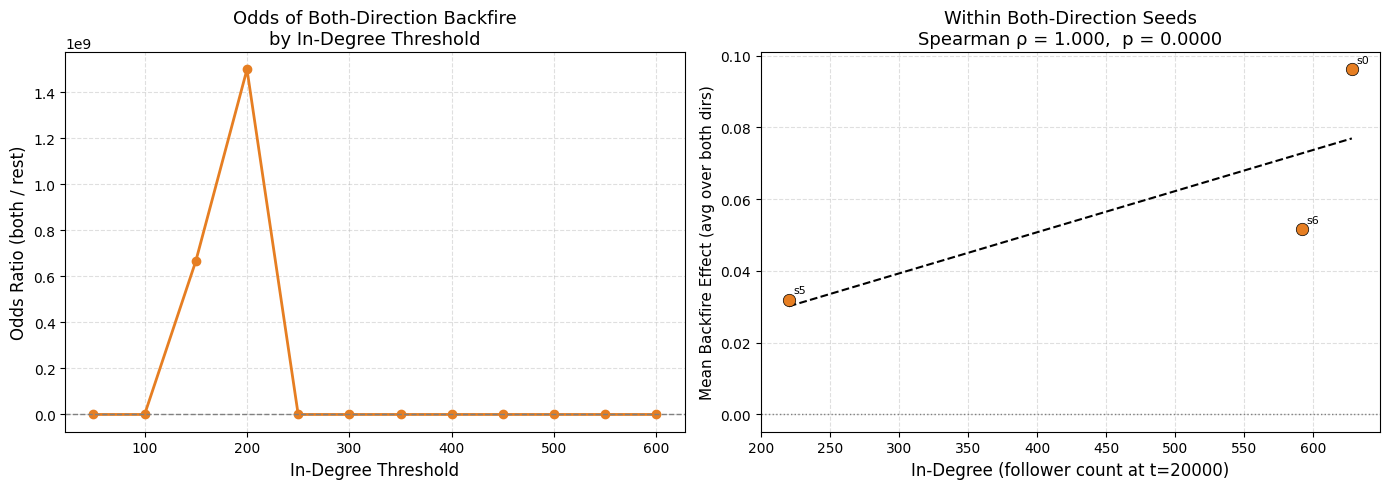

Saved: results/summary/BF_analysis/both_backfire_threshold.png

In-degree threshold — fraction above threshold & odds ratio
 threshold  both_frac  rest_frac         OR
       100      1.000      1.000       1.00
       200      1.000      0.400 1500000002.50
       300      0.667      0.400       3.00
       400      0.667      0.400       3.00
       500      0.667      0.200       8.00


In [16]:
# ---------------------------------------------------------------------------
# Fig 2: In-degree threshold odds-ratio curve + within-both scatter
# ---------------------------------------------------------------------------
fig, (ax_or, ax_sc) = plt.subplots(1, 2, figsize=(14, 5))

# -- Odds-ratio curve --
thresholds = list(range(50, 850, 50))
ors = []
for t in thresholds:
    f_b = (both_df['in_degree'] >= t).mean()
    f_r = (rest_df['in_degree'] >= t).mean()
    eps = 1e-9
    or_ = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))
    ors.append(or_)

ax_or.plot(thresholds, ors, 'o-', color='#e67e22', linewidth=2)
ax_or.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax_or.set_xlabel('In-Degree Threshold', fontsize=12)
ax_or.set_ylabel('Odds Ratio (both / rest)', fontsize=12)
ax_or.set_title('Odds of Both-Direction Backfire\nby In-Degree Threshold', fontsize=13)
ax_or.grid(True, linestyle='--', alpha=0.4)

# -- Scatter: within both-backfire, in_degree vs mean_backfire --
rho, p = sp_stats.spearmanr(both_df['in_degree'], both_df['mean_backfire'])
ax_sc.scatter(both_df['in_degree'], both_df['mean_backfire'],
              color='#e67e22', s=80, zorder=3, edgecolors='k', linewidths=0.5)

# label each seed
for _, row in both_df.iterrows():
    ax_sc.annotate(f"s{int(row['seed'])}", (row['in_degree'], row['mean_backfire']),
                   fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                   textcoords='offset points')

slope, intercept, *_ = sp_stats.linregress(both_df['in_degree'].values,
                                            both_df['mean_backfire'].values)
x_line = np.linspace(both_df['in_degree'].min(), both_df['in_degree'].max(), 200)
ax_sc.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)
ax_sc.axhline(0, color='gray', linestyle=':', linewidth=1)
ax_sc.set_xlabel('In-Degree (follower count at t=20000)', fontsize=12)
ax_sc.set_ylabel('Mean Backfire Effect (avg over both dirs)', fontsize=11)
ax_sc.set_title(f'Within Both-Direction Seeds\nSpearman ρ = {rho:.3f},  p = {p:.4f}', fontsize=13)
ax_sc.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, "both_backfire_threshold.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/BF_analysis/both_backfire_threshold.png")

# In-degree threshold table
print("\nIn-degree threshold — fraction above threshold & odds ratio")
print(f"{'threshold':>10} {'both_frac':>10} {'rest_frac':>10} {'OR':>10}")
for t in [100, 200, 300, 400, 500]:
    f_b = (both_df['in_degree'] >= t).mean()
    f_r = (rest_df['in_degree'] >= t).mean()
    eps = 1e-9
    OR = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))
    print(f"{t:>10} {f_b:>10.3f} {f_r:>10.3f} {OR:>10.2f}")

In [17]:
# ---------------------------------------------------------------------------
# Optional: save the per-run metrics table for further analysis
# ---------------------------------------------------------------------------
out_path = os.path.join(SUMMARY_DIR, "structural_backfire_table.csv")
df.to_csv(out_path, index=False)
print(f"Per-run table saved to {out_path}")
df

Per-run table saved to ./results/BF_analysis/structural_backfire_table.csv


,run_id,seed,target_sign,target_id,n_targets,backfire_effect,modularity,in_degree,betweenness,clustering,pagerank,eigenvector,target_opinion,follower_mean_opinion,follower_opinion_std,follower_homophily_frac,follower_dir_alignment
0,run_0_dir_-1.0,0,-1.0,0,1,0.107719,0.350182,628.0,0.000273,0.006697,0.165696,4.004997e-01,0.062669,0.100671,0.283789,0.630573,0.369427
1,run_0_dir_1.0,0,1.0,0,1,0.084558,0.350182,628.0,0.000273,0.006697,0.165696,4.004997e-01,0.064669,0.100671,0.283789,0.630573,0.630573
2,run_1_dir_-1.0,1,-1.0,4,1,0.034327,0.497084,195.0,0.000172,0.010929,0.015278,2.245961e-05,-0.150701,-0.206196,0.362109,0.723077,0.723077
3,run_1_dir_1.0,1,1.0,4,1,-0.040100,0.497084,195.0,0.000172,0.010929,0.015278,2.245961e-05,-0.150701,-0.206196,0.362109,0.723077,0.276923
4,run_2_dir_-1.0,2,-1.0,6,1,-0.041578,0.345301,407.0,0.000208,0.010943,0.013647,3.516643e-23,-0.082717,0.166363,0.319757,0.336609,0.336609
5,run_2_dir_1.0,2,1.0,6,1,0.164932,0.345301,407.0,0.000208,0.010943,0.013647,3.516643e-23,-0.082717,0.166363,0.319757,0.336609,0.663391
6,run_3_dir_-1.0,3,-1.0,11,1,-0.020818,0.311997,148.0,0.000075,0.025967,0.008882,2.079770e-05,-0.055680,0.085692,0.346923,0.364865,0.364865
7,run_3_dir_1.0,3,1.0,11,1,0.060828,0.311997,148.0,0.000075,0.025967,0.008882,2.079770e-05,-0.055680,0.085692,0.346923,0.364865,0.635135
8,run_5_dir_-1.0,5,-1.0,4,1,0.020964,0.342506,220.0,0.000170,0.015875,0.016552,1.953917e-05,-0.057761,0.004954,0.345804,0.427273,0.427273
9,run_5_dir_1.0,5,1.0,4,1,0.043043,0.342506,220.0,0.000170,0.015875,0.016552,1.953917e-05,-0.057761,0.004954,0.345804,0.427273,0.572727


## Agent-Level Changes in Opinion and Posting Probability Around Manipulation (Step 20000)

For each non-target agent we compute per-run averages:

| Window | Steps averaged |
|---|---|
| **pre** | 10000, 15000, 20000 — steady state just before manipulation |
| **post** | 20000, 25000, 30000 — immediate response to manipulation |

Metrics:
- **Δpostprob** = post_mean − pre_mean of `postProb` (positive = agent became more active)
- **Δopinion**  = post_mean − pre_mean of `opinion` (shift in expressed opinion)

**Opinion class is read from step 15000** (last GEXF snapshot before manipulation starts).  
Agents are grouped into **5 direction-relative positions**, ordered from most-opposing to most-aligned:

| Relative label | dir = +1 | dir = −1 |
|---|---|---|
| `far_opposite`  | bin 0 | bin 4 |
| `near_opposite` | bin 1 | bin 3 |
| `neutral`       | bin 2 | bin 2 |
| `near_target`   | bin 3 | bin 1 |
| `far_target`    | bin 4 | bin 0 |

The manipulated target node is **excluded** (its changes are externally forced).  
Each seed contributes two runs (dir = −1 and +1), both pooled within the seed's backfire class.

Since medians of Δpostprob are zero for all groups (most agents do not change at all), four complementary approaches are used to detect tail-driven counter-mobilisation:

1. **Activation rate** — fraction of agents with Δpostprob > threshold; Fisher's exact test (both vs rest per group)
2. **Upper quantiles** — 75th / 90th / 95th percentile of Δpostprob by group × class (sensitive to tail divergence invisible in box plots)
3. **KS test on full distributions** — Kolmogorov-Smirnov comparing both vs rest per group; ECDF plots
5. **Top-mover composition** — which groups are over-represented among the top 5% Δpostprob agents?

=== Method 1: Activation rate (Δpostprob > 0.01) ===
relative_group  far_opposite  near_opposite  neutral  near_target  far_target
backfire_class                                                               
both                  0.0918         0.1477    0.181       0.1632      0.1116
one                   0.0757         0.0982    0.117       0.1105      0.0700
neither                  NaN            NaN      NaN          NaN         NaN

Fisher's exact — both vs rest, per relative group:
  far_opposite      OR=1.234  p=0.1560  n.s.  (both=0.0918, rest=0.0757)
  near_opposite     OR=1.591  p=0.0000  **  (both=0.1477, rest=0.0982)
  neutral           OR=1.668  p=0.0000  **  (both=0.1810, rest=0.1170)
  near_target       OR=1.570  p=0.0000  **  (both=0.1632, rest=0.1105)


  far_target        OR=1.669  p=0.0004  **  (both=0.1116, rest=0.0700)


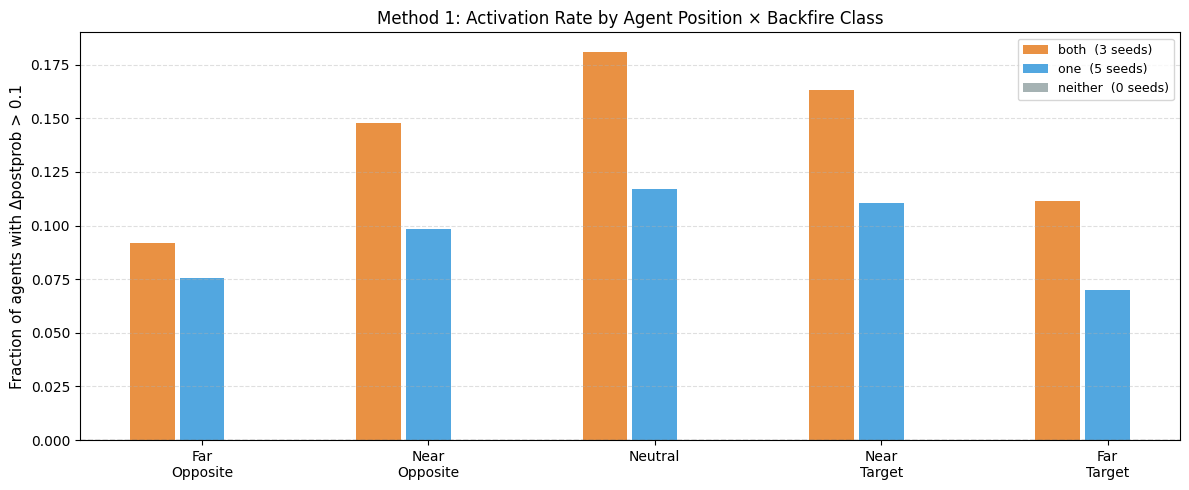

Saved: results/summary/BF_analysis/method1_activation_rate.png

=== Method 2: Upper quantiles of Δpostprob ===
relative_group       far_opposite  near_opposite   neutral  near_target  far_target
backfire_class                                                                     
both           0.75      0.001667       0.008858  0.024474     0.021562    0.004936
               0.90      0.077698       0.142623  0.146884     0.136557    0.106446
               0.95      0.146500       0.159905  0.186784     0.158319    0.146702
one            0.75      0.001129       0.001667  0.001667     0.002968    0.001521
               0.90      0.055391       0.098088  0.124905     0.112151    0.054063
               0.95      0.149892       0.153415  0.158611     0.150000    0.137535


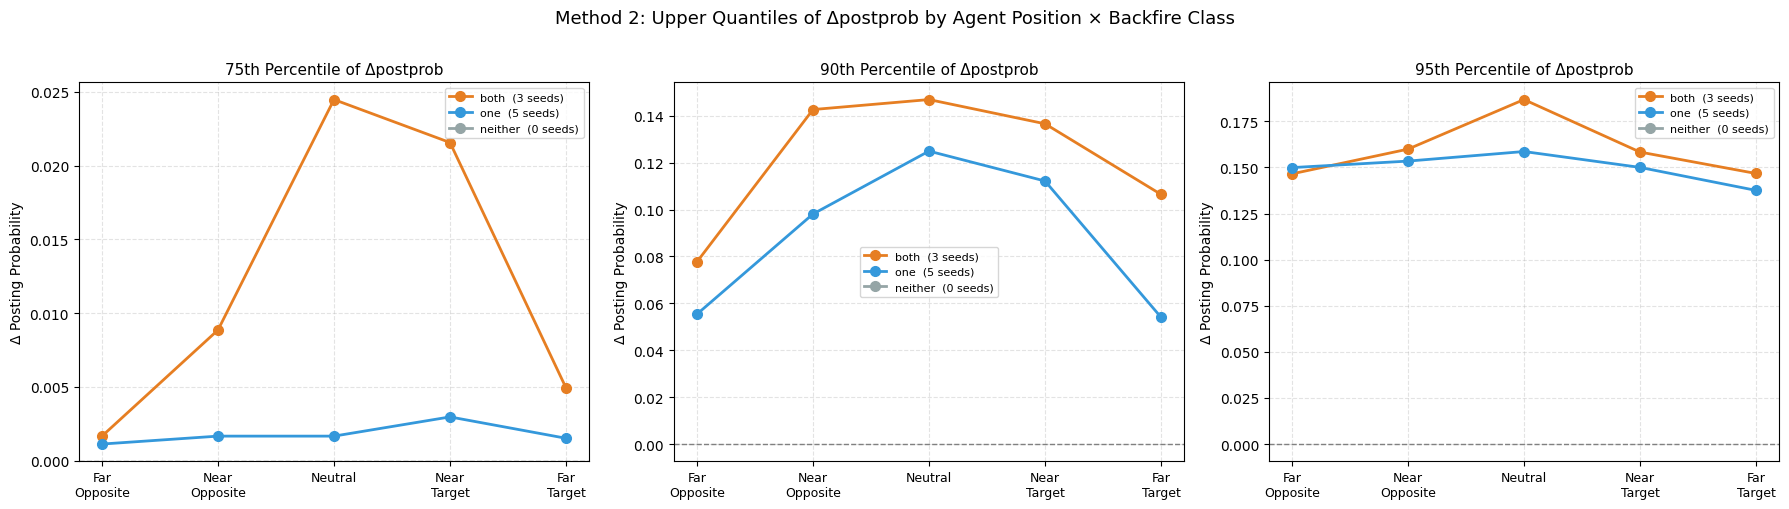

Saved: results/summary/BF_analysis/method2_upper_quantiles.png

=== Method 3: KS test — both vs rest, per relative group ===
  far_opposite      KS=0.0392  p=0.3099  n.s.
  near_opposite     KS=0.0649  p=0.0013  **
  neutral           KS=0.0908  p=0.0000  **
  near_target       KS=0.0942  p=0.0000  **
  far_target        KS=0.0738  p=0.0028  **


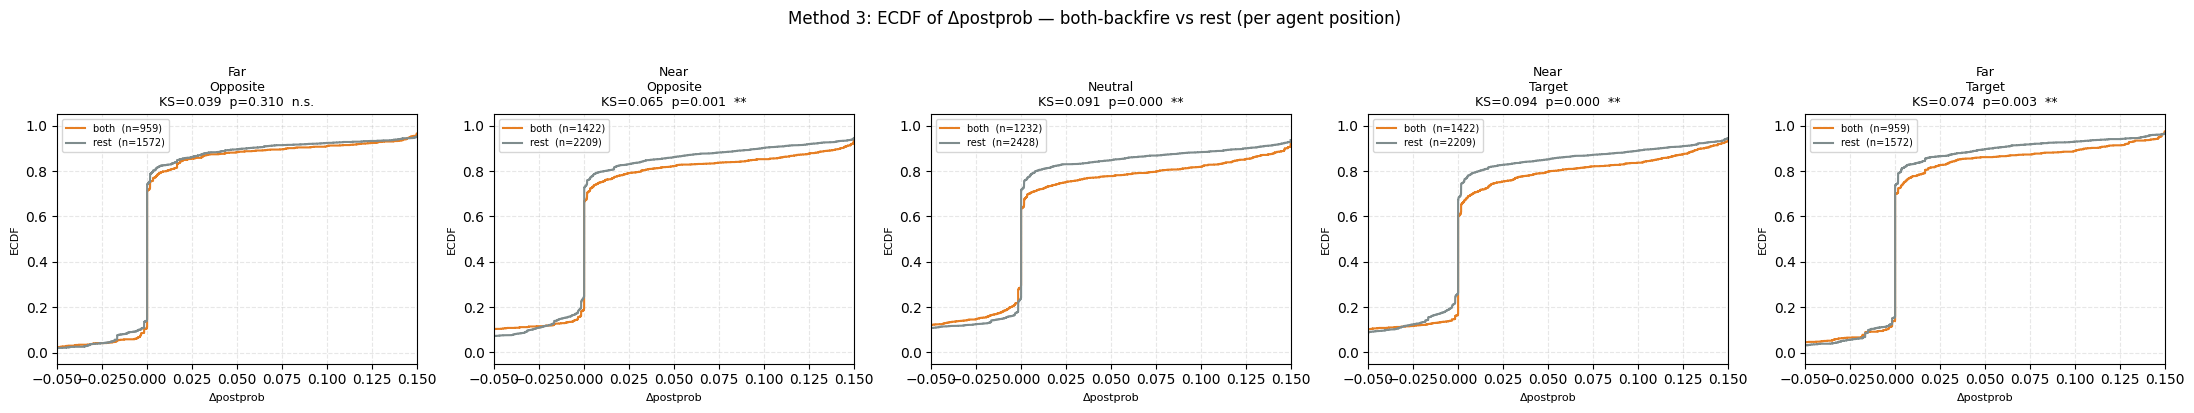

Saved: results/summary/BF_analysis/method3_ks_ecdf.png

=== Method 5: Group composition of top 5% Δpostprob movers (n=799) ===

Fraction within top movers (row-normalised):
relative_group  far_opposite  near_opposite  neutral  near_target  far_target
backfire_class                                                               
both                   0.103          0.277    0.290        0.255       0.075
one                    0.153          0.249    0.289        0.201       0.109

Chi-square on group composition of top movers: χ²=9.106  df=4  p=0.0585  n.s.
Fisher's exact — far_opposite enrichment (both vs rest): OR=0.636  p=0.0436  *


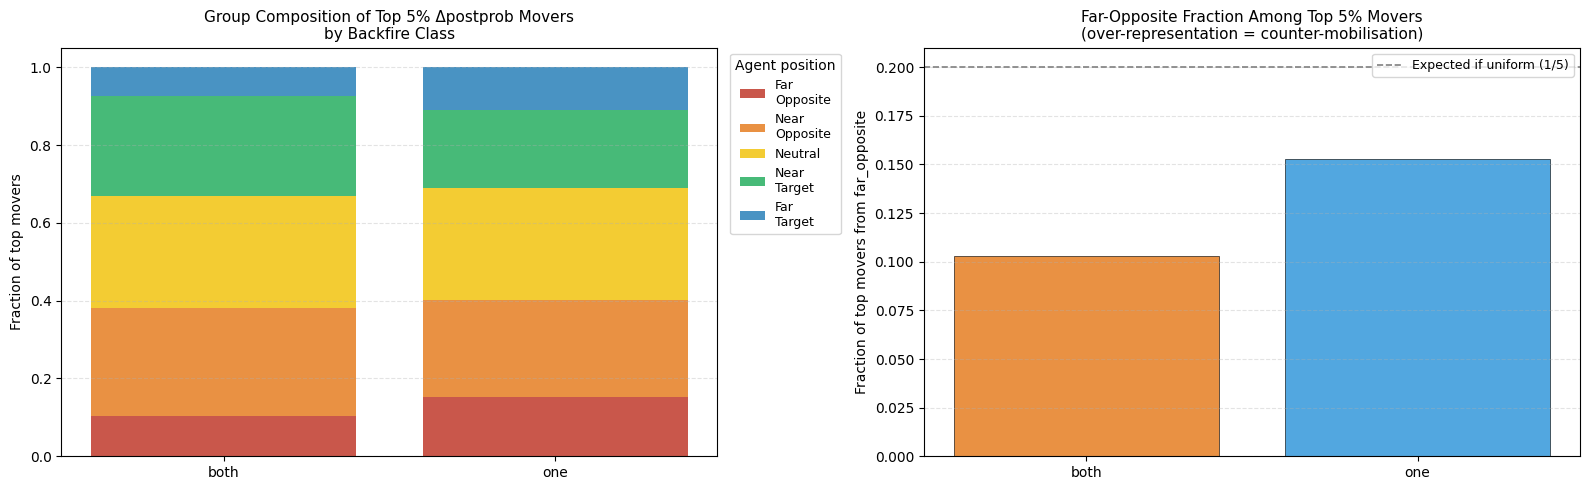

Saved: results/summary/BF_analysis/method5_top_movers_composition.png


In [18]:
from scipy.stats import fisher_exact, ks_2samp, chi2_contingency

CLASS_ORDER  = ['both', 'one', 'neither']
CLASS_COLORS = {'both': '#e67e22', 'one': '#3498db', 'neither': '#95a5a6'}
n_seeds_cls  = df_agents.groupby('backfire_class')['seed'].nunique().to_dict()

ng = len(GROUP_ORDER)
nc = len(CLASS_ORDER)

# =========================================================================
# Method 1: Activation rate + Fisher's exact test
# =========================================================================
ACTIVATION_THRESHOLD = 0.1
df_agents['activated'] = df_agents['delta_postprob'] > ACTIVATION_THRESHOLD

act_rate = (
    df_agents.groupby(['backfire_class', 'relative_group'])['activated']
    .mean()
    .unstack('relative_group')[GROUP_ORDER]
)
print("=== Method 1: Activation rate (Δpostprob > 0.01) ===")
print(act_rate.reindex(CLASS_ORDER).round(4).to_string())

print("\nFisher's exact — both vs rest, per relative group:")
for grp in GROUP_ORDER:
    sub      = df_agents[df_agents['relative_group'] == grp]
    b_act    = sub[sub['backfire_class'] == 'both']['activated']
    r_act    = sub[sub['backfire_class'] != 'both']['activated']
    table    = np.array([[b_act.sum(), len(b_act) - b_act.sum()],
                         [r_act.sum(), len(r_act) - r_act.sum()]])
    or_, p   = fisher_exact(table, alternative='two-sided')
    sig      = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    print(f"  {grp:16s}  OR={or_:.3f}  p={p:.4f}  {sig}  "
          f"(both={b_act.mean():.4f}, rest={r_act.mean():.4f})")

width   = 0.22
offsets = np.linspace(-(nc - 1) / 2 * width, (nc - 1) / 2 * width, nc)

fig, ax = plt.subplots(figsize=(12, 5))
for ci, cls in enumerate(CLASS_ORDER):
    sub   = df_agents[df_agents['backfire_class'] == cls]
    rates = [sub[sub['relative_group'] == grp]['activated'].mean() for grp in GROUP_ORDER]
    ax.bar(np.arange(ng) + offsets[ci], rates, width=width * 0.9,
           color=CLASS_COLORS[cls],
           label=f'{cls}  ({n_seeds_cls.get(cls, 0)} seeds)', alpha=0.85)
ax.set_xticks(range(ng))
ax.set_xticklabels(GROUP_LABELS, fontsize=10)
ax.set_ylabel(f'Fraction of agents with Δpostprob > {ACTIVATION_THRESHOLD}', fontsize=11)
ax.set_title('Method 1: Activation Rate by Agent Position × Backfire Class', fontsize=12)
ax.legend(fontsize=9)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, "method1_activation_rate.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/BF_analysis/method1_activation_rate.png")

# =========================================================================
# Method 2: Upper-quantile comparison (75th / 90th / 95th percentile)
# =========================================================================
QUANTILES = [0.75, 0.90, 0.95]
print("\n=== Method 2: Upper quantiles of Δpostprob ===")
qtab = (
    df_agents.groupby(['backfire_class', 'relative_group'])['delta_postprob']
    .quantile(QUANTILES)
    .unstack('relative_group')[GROUP_ORDER]
)
print(qtab.to_string())

fig, axes = plt.subplots(1, len(QUANTILES), figsize=(18, 5), sharey=False)
for ax, q in zip(axes, QUANTILES):
    for cls in CLASS_ORDER:
        vals = [
            df_agents[
                (df_agents['backfire_class'] == cls) &
                (df_agents['relative_group']  == grp)
            ]['delta_postprob'].quantile(q)
            for grp in GROUP_ORDER
        ]
        ax.plot(range(ng), vals, 'o-', color=CLASS_COLORS[cls],
                label=f'{cls}  ({n_seeds_cls.get(cls, 0)} seeds)',
                linewidth=2, markersize=7)
    ax.set_xticks(range(ng))
    ax.set_xticklabels(GROUP_LABELS, fontsize=9)
    ax.set_title(f'{int(q * 100)}th Percentile of Δpostprob', fontsize=11)
    ax.set_ylabel('Δ Posting Probability', fontsize=10)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.35)
plt.suptitle('Method 2: Upper Quantiles of Δpostprob by Agent Position × Backfire Class',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, "method2_upper_quantiles.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/BF_analysis/method2_upper_quantiles.png")

# =========================================================================
# Method 3: Kolmogorov-Smirnov test — full distribution comparison
# =========================================================================
print("\n=== Method 3: KS test — both vs rest, per relative group ===")

fig, axes = plt.subplots(1, ng, figsize=(22, 4), sharey=False)
for ax, grp, label in zip(axes, GROUP_ORDER, GROUP_LABELS):
    both_vals = df_agents[
        (df_agents['backfire_class'] == 'both') &
        (df_agents['relative_group']  == grp)
    ]['delta_postprob'].dropna().values
    rest_vals = df_agents[
        (df_agents['backfire_class'] != 'both') &
        (df_agents['relative_group']  == grp)
    ]['delta_postprob'].dropna().values

    stat, p = ks_2samp(both_vals, rest_vals)
    sig     = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    print(f"  {grp:16s}  KS={stat:.4f}  p={p:.4f}  {sig}")

    for vals, cls, color in [
        (both_vals, 'both', CLASS_COLORS['both']),
        (rest_vals, 'rest', '#7f8c8d'),
    ]:
        sv   = np.sort(vals)
        ecdf = np.arange(1, len(sv) + 1) / len(sv)
        ax.step(sv, ecdf, where='post', color=color,
                label=f'{cls}  (n={len(vals)})', linewidth=1.5)

    ax.set_title(f'{label}\nKS={stat:.3f}  p={p:.3f}  {sig}', fontsize=9)
    ax.set_xlabel('Δpostprob', fontsize=8)
    ax.set_xlim(-0.05, 0.15)
    ax.set_ylabel('ECDF', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Method 3: ECDF of Δpostprob — both-backfire vs rest (per agent position)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, "method3_ks_ecdf.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/BF_analysis/method3_ks_ecdf.png")

# =========================================================================
# Method 5: Group composition of top movers
# =========================================================================
TOP_FRAC = 0.05
top_k     = max(1, int(len(df_agents) * TOP_FRAC))
top_movers = df_agents.nlargest(top_k, 'delta_postprob')
print(f"\n=== Method 5: Group composition of top {int(TOP_FRAC * 100)}% Δpostprob movers (n={top_k}) ===")

comp = (
    top_movers.groupby(['backfire_class', 'relative_group']).size()
    .unstack('relative_group', fill_value=0)
    .reindex(columns=GROUP_ORDER, fill_value=0)
)
comp_frac = comp.div(comp.sum(axis=1), axis=0)
print("\nFraction within top movers (row-normalised):")
print(comp_frac.reindex([c for c in CLASS_ORDER if c in comp_frac.index]).round(3).to_string())

# Chi-square across all backfire classes
comp_arr = comp.reindex([c for c in CLASS_ORDER if c in comp.index]).values
if comp_arr.shape[0] >= 2:
    chi2, p_chi, dof, _ = chi2_contingency(comp_arr)
    sig = '**' if p_chi < 0.01 else ('*' if p_chi < 0.05 else 'n.s.')
    print(f"\nChi-square on group composition of top movers: χ²={chi2:.3f}  df={dof}  p={p_chi:.4f}  {sig}")

# Fisher's exact: far_opposite cell — both vs rest
fo_both = comp.loc['both', 'far_opposite'] if 'both' in comp.index else 0
fo_rest = comp.drop('both', errors='ignore')['far_opposite'].sum()
ot_both = comp.loc['both'].drop('far_opposite').sum() if 'both' in comp.index else 0
ot_rest = comp.drop('both', errors='ignore').drop('far_opposite', axis=1).values.sum()
or_fo, p_fo = fisher_exact([[fo_both, ot_both], [fo_rest, ot_rest]], alternative='two-sided')
sig_fo = '**' if p_fo < 0.01 else ('*' if p_fo < 0.05 else 'n.s.')
print(f"Fisher's exact — far_opposite enrichment (both vs rest): OR={or_fo:.3f}  p={p_fo:.4f}  {sig_fo}")

fig, (ax_stack, ax_bar) = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar: group composition of top movers per backfire class
palette  = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#2980b9']
classes_present = [c for c in CLASS_ORDER if c in comp_frac.index]
bottom   = np.zeros(len(classes_present))
for gi, (grp, lbl) in enumerate(zip(GROUP_ORDER, GROUP_LABELS)):
    vals = comp_frac.reindex(classes_present)[grp].fillna(0).values
    ax_stack.bar(classes_present, vals, bottom=bottom,
                 color=palette[gi], label=lbl, alpha=0.85)
    bottom += vals
ax_stack.set_title(f'Group Composition of Top {int(TOP_FRAC * 100)}% Δpostprob Movers\nby Backfire Class',
                   fontsize=11)
ax_stack.set_ylabel('Fraction of top movers', fontsize=10)
ax_stack.legend(title='Agent position', fontsize=9,
                bbox_to_anchor=(1.01, 1), loc='upper left')
ax_stack.grid(axis='y', linestyle='--', alpha=0.35)

# Bar: far_opposite fraction vs expected baseline (1/5)
fo_fracs = comp_frac['far_opposite'].reindex(classes_present, fill_value=0)
ax_bar.bar(classes_present, fo_fracs.values,
           color=[CLASS_COLORS.get(c, '#aaa') for c in classes_present],
           alpha=0.85, edgecolor='k', linewidth=0.5)
ax_bar.axhline(1 / ng, color='gray', linestyle='--', linewidth=1.2,
               label=f'Expected if uniform (1/{ng})')
ax_bar.set_title(f'Far-Opposite Fraction Among Top {int(TOP_FRAC * 100)}% Movers\n'
                 f'(over-representation = counter-mobilisation)',
                 fontsize=11)
ax_bar.set_ylabel('Fraction of top movers from far_opposite', fontsize=10)
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, "method5_top_movers_composition.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/BF_analysis/method5_top_movers_composition.png")